# Notebook 39 — Parameter-set-specific SOC/Q τ₂-rebased frequency scheduling

## Goal

Build a parameter-set-specific SOC/Q relaxation-time map and use it later for phase-continuous frequency scheduling:

```text
f(Q) = 1 / (2π · k · τ₂(Q))
```

Day39 follows Day38, where the amplitude/window policy was optimized at a fixed frequency.

Day39 changes the frequency schedule, not the amplitude/window policy.

## Scientific context

Day38 identified the current primary fixed-frequency candidate:

```text
local_H_high_early_early_off
early_ac_c = 0.38
mid_ac_c = 0.05
qfrac_derate = 0.62
qfrac_ac_off = 0.77
```

Day39 keeps this amplitude/window schedule fixed and tests whether SOC/Q-segmented τ₂-rebased frequency scheduling improves the gain–margin–microstate trade-off.

## Critical methodological locks

### 1. τ₂ is parameter-set-specific

The τ₂ map must be extracted from the same parameter set, model type, thermal setting, and temperature used by the frequency-scheduling simulation.

For this notebook:

```text
parameter_set = Chen2020
model = DFN
thermal = isothermal
temperature = Chen2020 default / 298.15 K reference
```

Do not borrow τ₂ from MJ1 experiments, Day17 global τ_ref, or another parameter set.

### 2. PyBaMM current sign convention

PyBaMM uses:

```text
+I = discharge
−I = charge
```

This project uses a human-readable external convention:

```text
I_charge_A > 0 means charge direction
```

Therefore, every prescribed-current waveform must use:

```text
I_py_A = -I_charge_A
```

This sign rule applies to both local pulse-rest τ₂ extraction and DC–AC frequency-scheduled charging.

## Day39A scope

Day39A extracts a local pulse-rest τ₂(Q) map along a DC precharge trajectory.

For each Q/SOC target:

1. Start from `initial_soc = 0.05`.
2. Precharge at DC 0.3C until the target Q fraction of the DC reference charge is reached.
3. Rest.
4. Apply a local charge pulse.
5. Rest.
6. Fit the voltage relaxation after the pulse using a bi-exponential model.
7. Extract τ₂ as the slower fitted time constant.

This is an HPPC-like local relaxation audit for the Chen2020 / DFN parameter set.

## Interpretation boundary

- The extracted τ₂ values are local descriptors for frequency scheduling, not universal cell constants.
- If a fit fails or produces nonphysical τ₂, that segment must fall back to a conservative default rather than being forced.
- Day39A does not yet run DC–AC frequency scheduling; it only builds the τ₂(Q) map.

In [1]:
# Cell 1 — Imports, paths, and Day39 metadata（导入库、路径与Day39元数据）

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybamm
from scipy.optimize import curve_fit

warnings.filterwarnings("default")

REPO = Path("/Users/louislu/pybamm-dcac-superimposed")
DATA_DIR = REPO / "data"
FIG_DIR = REPO / "figures"
DOCS_DIR = REPO / "docs"

for p in [DATA_DIR, FIG_DIR, DOCS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

PRIMARY_PARAMETER_SET = "Chen2020"
MODEL_TYPE = "DFN"
THERMAL_MODE = "isothermal"
FREQUENCY_MODE = "soc_q_segment_tau2_rebased"

DC_C = 0.3
INITIAL_SOC = 0.05

# Day38 primary fixed-frequency candidate. Day39 keeps amplitude/window fixed first.
LOCAL_H_POLICY = {
    "policy_id": "local_H_high_early_early_off",
    "early_ac_c": 0.38,
    "mid_ac_c": 0.05,
    "qfrac_derate": 0.62,
    "qfrac_ac_off": 0.77,
    "tau_factor_reference": 1.5,
}

# Previous global descriptor for fallback only, not as primary τ₂(Q) map.
TAU_REF_SET_S_FALLBACK = 36.316532231592305

parameter_values = pybamm.ParameterValues(PRIMARY_PARAMETER_SET)
Q_NOM_AH = float(parameter_values["Nominal cell capacity [A.h]"])
I_DC_A = DC_C * Q_NOM_AH

DAY39_METADATA = {
    "notebook": "39_soc_tau_frequency_scheduling.ipynb",
    "parameter_set": PRIMARY_PARAMETER_SET,
    "model_type": MODEL_TYPE,
    "thermal": THERMAL_MODE,
    "frequency_mode": FREQUENCY_MODE,
    "initial_soc": INITIAL_SOC,
    "dc_c": DC_C,
    "nominal_capacity_Ah": Q_NOM_AH,
    "I_DC_A": I_DC_A,
    "local_H_policy": LOCAL_H_POLICY,
    "critical_sign_rule": "project I_charge_A > 0 for charge; PyBaMM I_py_A = -I_charge_A",
    "purpose": "extract parameter-set-specific τ2(Q) map before SOC/Q-segmented frequency scheduling",
}

metadata_path = DATA_DIR / "day39_metadata.json"
metadata_path.write_text(json.dumps(DAY39_METADATA, indent=2), encoding="utf-8")

print("[OK] repo:", REPO)
print("[OK] pybamm version:", pybamm.__version__)
print("[OK] Q_NOM_AH:", Q_NOM_AH)
print("[OK] I_DC_A:", I_DC_A)
print("[OK] saved metadata:", metadata_path)

[OK] repo: /Users/louislu/pybamm-dcac-superimposed
[OK] pybamm version: 26.3.1
[OK] Q_NOM_AH: 5.0
[OK] I_DC_A: 1.5
[OK] saved metadata: /Users/louislu/pybamm-dcac-superimposed/data/day39_metadata.json


In [2]:
# Cell 2 — Load DC reference and define τ₂ extraction targets（读取DC基准并定义τ₂提取目标）

candidate_ref_files = [
    DATA_DIR / "day38_seed_run_summary.csv",
    DATA_DIR / "day35_run_summary.csv",
    DATA_DIR / "day34_run_summary.csv",
]

Q_REF_AH = None
REF_SOURCE = None

for path in candidate_ref_files:
    if path.exists():
        df = pd.read_csv(path)
        # Prefer Day38 DC reference if available.
        if "policy_id" in df.columns:
            dc_rows = df[df["policy_id"].astype(str).str.contains("DC03")]
        else:
            dc_rows = df[
                df["condition"].astype(str).str.contains("DC03")
                & ~df["condition"].astype(str).str.contains("AC")
            ]
        if len(dc_rows) > 0 and "Q_end_Ah" in dc_rows.columns:
            Q_REF_AH = float(dc_rows["Q_end_Ah"].iloc[0])
            REF_SOURCE = str(path)
            break

if Q_REF_AH is None:
    Q_REF_AH = 4.4928790028035
    REF_SOURCE = "fallback_historical"
    print("[WARN] fallback Q_REF_AH used:", Q_REF_AH)

# Targets along the DC charge trajectory.
# 0.85 is kept as diagnostic, although local_H turns AC off at 0.77.
QFRAC_TARGETS = [0.20, 0.40, 0.60, 0.72, 0.85]

target_rows = []

for qfrac in QFRAC_TARGETS:
    q_target_Ah = qfrac * Q_REF_AH
    precharge_s = q_target_Ah * 3600.0 / I_DC_A

    if qfrac < LOCAL_H_POLICY["qfrac_derate"]:
        segment_role = "early_high_AC_region"
    elif qfrac < LOCAL_H_POLICY["qfrac_ac_off"]:
        segment_role = "mid_low_AC_region"
    else:
        segment_role = "diagnostic_AC_off_region"

    target_rows.append({
        "parameter_set": PRIMARY_PARAMETER_SET,
        "model_type": MODEL_TYPE,
        "thermal": THERMAL_MODE,
        "qfrac_target": qfrac,
        "Q_target_Ah": q_target_Ah,
        "precharge_s_at_0p3C": precharge_s,
        "precharge_min_at_0p3C": precharge_s / 60.0,
        "segment_role_for_local_H": segment_role,
        "Q_ref_Ah": Q_REF_AH,
        "Q_ref_source": REF_SOURCE,
    })

tau_target_df = pd.DataFrame(target_rows)

out = DATA_DIR / "day39_tau2_extraction_targets.csv"
tau_target_df.to_csv(out, index=False)

print("[OK] Q_REF_AH:", Q_REF_AH)
print("[OK] Q_REF source:", REF_SOURCE)
print("[OK] saved targets:", out)
display(tau_target_df)


[OK] Q_REF_AH: 4.4928790028035
[OK] Q_REF source: /Users/louislu/pybamm-dcac-superimposed/data/day38_seed_run_summary.csv
[OK] saved targets: /Users/louislu/pybamm-dcac-superimposed/data/day39_tau2_extraction_targets.csv


,parameter_set,model_type,thermal,qfrac_target,Q_target_Ah,precharge_s_at_0p3C,precharge_min_at_0p3C,segment_role_for_local_H,Q_ref_Ah,Q_ref_source
0,Chen2020,DFN,isothermal,0.20,0.898576,2156.581921,35.943032,early_high_AC_region,4.492879,/Users/louislu/pybamm-dcac-superimposed/data/d...
1,Chen2020,DFN,isothermal,0.40,1.797152,4313.163843,71.886064,early_high_AC_region,4.492879,/Users/louislu/pybamm-dcac-superimposed/data/d...
2,Chen2020,DFN,isothermal,0.60,2.695727,6469.745764,107.829096,early_high_AC_region,4.492879,/Users/louislu/pybamm-dcac-superimposed/data/d...
3,Chen2020,DFN,isothermal,0.72,3.234873,7763.694917,129.394915,mid_low_AC_region,4.492879,/Users/louislu/pybamm-dcac-superimposed/data/d...
4,Chen2020,DFN,isothermal,0.85,3.818947,9165.473166,152.757886,diagnostic_AC_off_region,4.492879,/Users/louislu/pybamm-dcac-superimposed/data/d...


In [3]:
# Cell 3 — Local pulse-rest current-profile utilities with PyBaMM sign audit（局部脉冲-静置电流工具与符号审计）

# HPPC-like local relaxation protocol.
# Pulse is in charge direction and must be converted to PyBaMM negative current.
REST_BEFORE_PULSE_S = 300.0
PULSE_C_RATE = 0.3
PULSE_DURATION_S = 30.0
REST_AFTER_PULSE_S = 900.0
PROFILE_DT_S = 1.0

I_PULSE_CHARGE_A = PULSE_C_RATE * Q_NOM_AH

def make_local_tau_profile(qfrac_target):
    """
    Build a charge-positive profile for:
    precharge -> rest -> charge pulse -> rest.

    Project convention:
        I_charge_A > 0 = charge

    PyBaMM convention:
        I_py_A = -I_charge_A
    """
    q_target_Ah = qfrac_target * Q_REF_AH
    precharge_s = q_target_Ah * 3600.0 / I_DC_A

    t_pre_end = precharge_s
    t_rest1_end = t_pre_end + REST_BEFORE_PULSE_S
    t_pulse_end = t_rest1_end + PULSE_DURATION_S
    t_total = t_pulse_end + REST_AFTER_PULSE_S

    t_grid = np.arange(0.0, t_total + PROFILE_DT_S, PROFILE_DT_S)
    i_charge = np.zeros_like(t_grid)

    # DC precharge
    i_charge[(t_grid >= 0.0) & (t_grid < t_pre_end)] = I_DC_A

    # Rest before pulse remains zero

    # Local charge pulse
    i_charge[(t_grid >= t_rest1_end) & (t_grid < t_pulse_end)] = I_PULSE_CHARGE_A

    # Rest after pulse remains zero

    i_py = -i_charge

    profile_df = pd.DataFrame({
        "t_s": t_grid,
        "I_charge_A": i_charge,
        "I_py_A": i_py,
    })

    meta = {
        "qfrac_target": qfrac_target,
        "Q_target_Ah": q_target_Ah,
        "precharge_s": precharge_s,
        "t_pre_end_s": t_pre_end,
        "t_rest1_end_s": t_rest1_end,
        "t_pulse_end_s": t_pulse_end,
        "t_total_s": t_total,
        "I_DC_charge_A": I_DC_A,
        "I_pulse_charge_A": I_PULSE_CHARGE_A,
        "pulse_c_rate": PULSE_C_RATE,
        "pulse_duration_s": PULSE_DURATION_S,
        "rest_before_pulse_s": REST_BEFORE_PULSE_S,
        "rest_after_pulse_s": REST_AFTER_PULSE_S,
        "sign_rule": "I_py_A = -I_charge_A",
    }

    return profile_df, meta


# Sign audit for all targets.
sign_rows = []

for qfrac in QFRAC_TARGETS:
    prof, meta = make_local_tau_profile(qfrac)
    pulse_mask = (prof["t_s"] >= meta["t_rest1_end_s"]) & (prof["t_s"] < meta["t_pulse_end_s"])
    pre_mask = (prof["t_s"] >= 0.0) & (prof["t_s"] < meta["t_pre_end_s"])

    sign_rows.append({
        "qfrac_target": qfrac,
        "precharge_I_charge_mean_A": float(prof.loc[pre_mask, "I_charge_A"].mean()),
        "precharge_I_py_mean_A": float(prof.loc[pre_mask, "I_py_A"].mean()),
        "pulse_I_charge_mean_A": float(prof.loc[pulse_mask, "I_charge_A"].mean()),
        "pulse_I_py_mean_A": float(prof.loc[pulse_mask, "I_py_A"].mean()),
        "precharge_sign_ok": bool((prof.loc[pre_mask, "I_charge_A"].mean() > 0) and (prof.loc[pre_mask, "I_py_A"].mean() < 0)),
        "pulse_sign_ok": bool((prof.loc[pulse_mask, "I_charge_A"].mean() > 0) and (prof.loc[pulse_mask, "I_py_A"].mean() < 0)),
        "t_total_s": meta["t_total_s"],
    })

sign_audit_df = pd.DataFrame(sign_rows)

out = DATA_DIR / "day39_tau2_pulse_profile_sign_audit.csv"
sign_audit_df.to_csv(out, index=False)

print("[OK] saved sign audit:", out)
display(sign_audit_df)

if not (sign_audit_df["precharge_sign_ok"].all() and sign_audit_df["pulse_sign_ok"].all()):
    raise RuntimeError("PyBaMM sign audit failed. Do not continue.")


[OK] saved sign audit: /Users/louislu/pybamm-dcac-superimposed/data/day39_tau2_pulse_profile_sign_audit.csv


,qfrac_target,precharge_I_charge_mean_A,precharge_I_py_mean_A,pulse_I_charge_mean_A,pulse_I_py_mean_A,precharge_sign_ok,pulse_sign_ok,t_total_s
0,0.20,1.5,-1.5,1.5,-1.5,True,True,3386.581921
1,0.40,1.5,-1.5,1.5,-1.5,True,True,5543.163843
2,0.60,1.5,-1.5,1.5,-1.5,True,True,7699.745764
3,0.72,1.5,-1.5,1.5,-1.5,True,True,8993.694917
4,0.85,1.5,-1.5,1.5,-1.5,True,True,10395.473166


In [6]:
# Cell 3B — Cumulative trapezoid utility（累积梯形积分工具）

def cumulative_trapezoid_np(y, x):
    """
    Lightweight cumulative trapezoidal integration.

    Used for:
    - Q_net(t) = ∫ I_charge(t) dt
    - geometry / first-passage utilities in later cells
    """
    y = np.asarray(y, dtype=float).reshape(-1)
    x = np.asarray(x, dtype=float).reshape(-1)

    if len(y) != len(x):
        raise ValueError("x and y length mismatch")

    if len(y) < 2:
        return np.zeros_like(y)

    dx = np.diff(x)
    area = 0.5 * (y[:-1] + y[1:]) * dx

    return np.concatenate([[0.0], np.cumsum(area)])


print("[OK] cumulative_trapezoid_np is defined.")

[OK] cumulative_trapezoid_np is defined.


In [7]:
# Cell 4 — Run local pulse-rest simulations for τ₂ extraction（运行局部脉冲-静置仿真提取τ₂）

def make_tau_extraction_model():
    return pybamm.lithium_ion.DFN({
        "thermal": THERMAL_MODE,
        "surface form": "false",
    })


def run_local_tau_simulation(qfrac_target, n_eval_max=5000):
    profile_df, meta = make_local_tau_profile(qfrac_target)

    current_interpolant = pybamm.Interpolant(
        profile_df["t_s"].to_numpy(),
        profile_df["I_py_A"].to_numpy(),
        pybamm.t,
        interpolator="linear",
    )

    pv = pybamm.ParameterValues(PRIMARY_PARAMETER_SET)
    pv.update({"Current function [A]": current_interpolant}, check_already_exists=False)

    model = make_tau_extraction_model()
    sim = pybamm.Simulation(model, parameter_values=pv)

    n_eval = min(n_eval_max, max(1200, int(meta["t_total_s"] // 2)))
    t_eval = np.linspace(0.0, meta["t_total_s"], n_eval)

    sol = sim.solve(t_eval=t_eval, initial_soc=INITIAL_SOC)

    t_s = np.asarray(sol.t, dtype=float)
    V = np.asarray(sol["Terminal voltage [V]"](t_s), dtype=float).reshape(-1)
    I_py = np.asarray(sol["Current [A]"](t_s), dtype=float).reshape(-1)
    I_charge = -I_py

    ts = pd.DataFrame({
        "t_s": t_s,
        "V_terminal_V": V,
        "I_py_A": I_py,
        "I_charge_A": I_charge,
    })

    # Add integrated charge for traceability.
    ts["Q_net_Ah"] = cumulative_trapezoid_np(ts["I_charge_A"].to_numpy(), ts["t_s"].to_numpy()) / 3600.0

    return {
        "qfrac_target": qfrac_target,
        "profile": profile_df,
        "meta": meta,
        "sim": sim,
        "sol": sol,
        "ts": ts,
    }


tau_sim_results = {}
run_rows = []

for qfrac in QFRAC_TARGETS:
    print(f"\n[RUN TAU] qfrac={qfrac}")

    try:
        result = run_local_tau_simulation(qfrac)
        tau_sim_results[qfrac] = result
        ts = result["ts"]
        meta = result["meta"]

        run_rows.append({
            "qfrac_target": qfrac,
            "status": "ok",
            "termination": str(result["sol"].termination),
            "t_total_s": meta["t_total_s"],
            "t_total_min": meta["t_total_s"] / 60.0,
            "Q_end_Ah": float(ts["Q_net_Ah"].iloc[-1]),
            "V_start_V": float(ts["V_terminal_V"].iloc[0]),
            "V_end_V": float(ts["V_terminal_V"].iloc[-1]),
            "I_charge_min_A": float(ts["I_charge_A"].min()),
            "I_charge_max_A": float(ts["I_charge_A"].max()),
            "error": "",
        })

        print("[OK] qfrac", qfrac, "| termination:", result["sol"].termination)

    except Exception as e:
        run_rows.append({
            "qfrac_target": qfrac,
            "status": "failed",
            "termination": "",
            "t_total_s": np.nan,
            "t_total_min": np.nan,
            "Q_end_Ah": np.nan,
            "V_start_V": np.nan,
            "V_end_V": np.nan,
            "I_charge_min_A": np.nan,
            "I_charge_max_A": np.nan,
            "error": repr(e),
        })
        print("[FAILED] qfrac", qfrac, repr(e))

tau_run_summary_df = pd.DataFrame(run_rows)

out = DATA_DIR / "day39_tau2_local_pulse_run_summary.csv"
tau_run_summary_df.to_csv(out, index=False)

print("[OK] saved local τ₂ run summary:", out)
display(tau_run_summary_df)


[RUN TAU] qfrac=0.2
[OK] qfrac 0.2 | termination: final time

[RUN TAU] qfrac=0.4
[OK] qfrac 0.4 | termination: final time

[RUN TAU] qfrac=0.6
[OK] qfrac 0.6 | termination: final time

[RUN TAU] qfrac=0.72
[OK] qfrac 0.72 | termination: final time

[RUN TAU] qfrac=0.85
[OK] qfrac 0.85 | termination: final time
[OK] saved local τ₂ run summary: /Users/louislu/pybamm-dcac-superimposed/data/day39_tau2_local_pulse_run_summary.csv


,qfrac_target,status,termination,t_total_s,t_total_min,Q_end_Ah,V_start_V,V_end_V,I_charge_min_A,I_charge_max_A,error
0,0.20,ok,final time,3386.581921,56.443032,0.911042,3.177214,3.507611,-0.0,1.5,
1,0.40,ok,final time,5543.163843,92.386064,1.809792,3.177214,3.668216,-0.0,1.5,
2,0.60,ok,final time,7699.745764,128.329096,2.708125,3.177214,3.822098,-0.0,1.5,
3,0.72,ok,final time,8993.694917,149.894915,3.247292,3.177214,3.927094,-0.0,1.5,
4,0.85,ok,final time,10395.473166,173.257886,3.831459,3.177214,4.036486,-0.0,1.5,


[FIT] 0.2


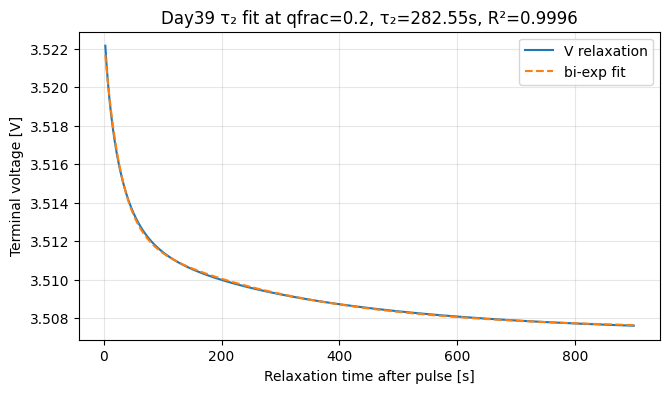

[FIT] 0.4


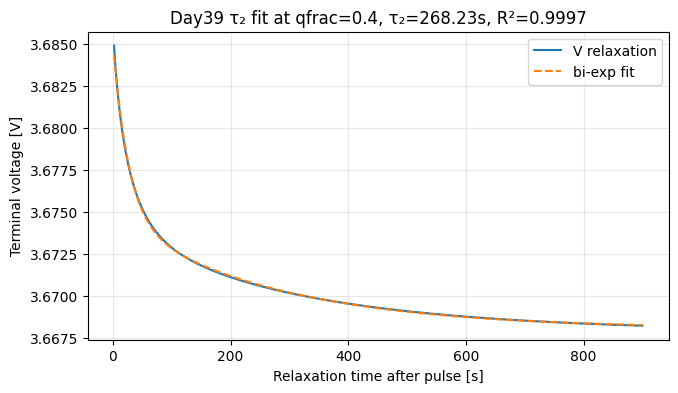

[FIT] 0.6


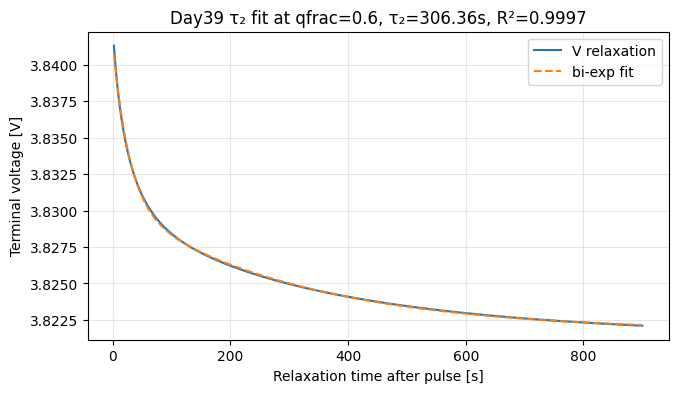

[FIT] 0.72


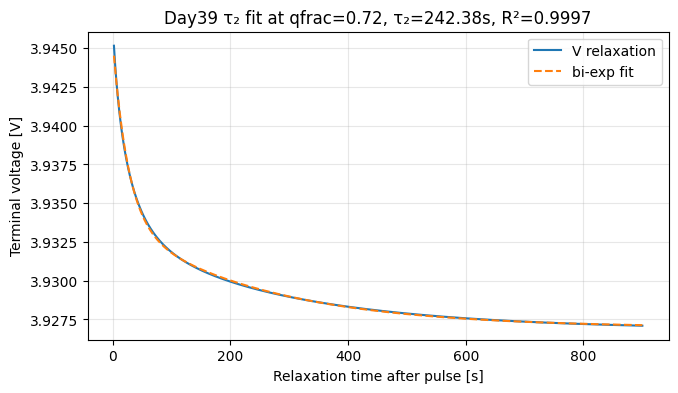

[FIT] 0.85


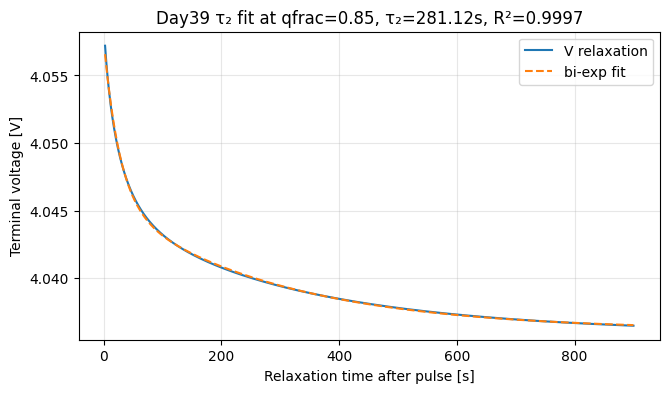

[OK] saved τ₂(Q) map: /Users/louislu/pybamm-dcac-superimposed/data/day39_tau2_soc_q_map.csv
[OK] saved τ₂ fit curves: /Users/louislu/pybamm-dcac-superimposed/data/day39_tau2_fit_curves.csv


,parameter_set,model_type,thermal,qfrac_target,Q_target_Ah,precharge_s_at_0p3C,precharge_min_at_0p3C,segment_role_for_local_H,Q_ref_Ah,Q_ref_source,...,tau2_raw_s,tau_fast_s,tau_slow_s,tau2_selected_s,fit_R2,fit_rmse_mV,fit_status,tau_valid_for_frequency,frequency_f_Hz_k1p5,period_s_k1p5
0,Chen2020,DFN,isothermal,0.20,0.898576,2156.581921,35.943032,early_high_AC_region,4.492879,/Users/louislu/pybamm-dcac-superimposed/data/d...,...,282.546335,26.698289,282.546335,282.546335,0.999638,0.045027,ok,True,0.000376,2662.936474
1,Chen2020,DFN,isothermal,0.40,1.797152,4313.163843,71.886064,early_high_AC_region,4.492879,/Users/louislu/pybamm-dcac-superimposed/data/d...,...,268.229567,25.987695,268.229567,268.229567,0.999672,0.049675,ok,True,0.000396,2528.004115
2,Chen2020,DFN,isothermal,0.60,2.695727,6469.745764,107.829096,early_high_AC_region,4.492879,/Users/louislu/pybamm-dcac-superimposed/data/d...,...,306.361231,27.136983,306.361231,306.361231,0.999716,0.056132,ok,True,0.000346,2887.386581
3,Chen2020,DFN,isothermal,0.72,3.234873,7763.694917,129.394915,mid_low_AC_region,4.492879,/Users/louislu/pybamm-dcac-superimposed/data/d...,...,242.383642,25.554478,242.383642,242.383642,0.999653,0.054074,ok,True,0.000438,2284.412005
4,Chen2020,DFN,isothermal,0.85,3.818947,9165.473166,152.757886,diagnostic_AC_off_region,4.492879,/Users/louislu/pybamm-dcac-superimposed/data/d...,...,281.117311,26.563463,281.117311,281.117311,0.999741,0.057831,ok,True,0.000377,2649.468240


In [8]:
# Cell 5 — Fit bi-exponential relaxation and build τ₂(Q) map（拟合双指数弛豫并建立τ₂(Q)图谱）

def biexponential_relaxation(t, U_inf, A1, tau1, A2, tau2):
    return U_inf + A1 * np.exp(-t / tau1) + A2 * np.exp(-t / tau2)


def fit_tau2_from_relaxation(ts, meta, fit_start_s=2.0):
    # Select post-pulse rest segment.
    rest = ts[ts["t_s"] >= meta["t_pulse_end_s"]].copy()
    rest["t_rel_s"] = rest["t_s"] - meta["t_pulse_end_s"]
    rest = rest[rest["t_rel_s"] >= fit_start_s].copy()

    t = rest["t_rel_s"].to_numpy()
    y = rest["V_terminal_V"].to_numpy()

    if len(t) < 50:
        return None, rest, "too_few_points"

    # Normalize time by actual seconds, use robust initial guesses.
    U0 = float(y[0])
    Uend = float(y[-1])
    amp = U0 - Uend

    # For charge-pulse relaxation, voltage commonly decays downward after pulse.
    # Sign can vary; allow both signs in bounds.
    p0 = [
        Uend,          # U_inf
        0.6 * amp,     # A1
        20.0,          # tau1
        0.4 * amp,     # A2
        200.0,         # tau2
    ]

    bounds_lower = [2.0, -1.0, 0.5, -1.0, 5.0]
    bounds_upper = [5.0,  1.0, 500.0,  1.0, 3000.0]

    try:
        popt, pcov = curve_fit(
            biexponential_relaxation,
            t,
            y,
            p0=p0,
            bounds=(bounds_lower, bounds_upper),
            maxfev=50000,
        )

        yhat = biexponential_relaxation(t, *popt)
        ss_res = float(np.sum((y - yhat) ** 2))
        ss_tot = float(np.sum((y - np.mean(y)) ** 2))
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

        U_inf, A1, tau1, A2, tau2 = popt

        # Sort tau values into fast/slow for interpretability.
        taus = sorted([float(tau1), float(tau2)])
        tau_fast_s, tau_slow_s = taus[0], taus[1]

        fit = {
            "U_inf_V": float(U_inf),
            "A1_V": float(A1),
            "tau1_raw_s": float(tau1),
            "A2_V": float(A2),
            "tau2_raw_s": float(tau2),
            "tau_fast_s": tau_fast_s,
            "tau_slow_s": tau_slow_s,
            "tau2_selected_s": tau_slow_s,
            "fit_R2": float(r2),
            "fit_rmse_mV": float(np.sqrt(np.mean((y - yhat) ** 2)) * 1000.0),
            "fit_status": "ok",
        }

        return fit, rest.assign(V_fit_V=yhat), "ok"

    except Exception as e:
        return None, rest, f"fit_failed: {repr(e)}"


fit_rows = []
fit_curve_records = []

for qfrac, result in tau_sim_results.items():
    print("[FIT]", qfrac)
    fit, rest_fit_df, status = fit_tau2_from_relaxation(result["ts"], result["meta"])

    target_row = tau_target_df[tau_target_df["qfrac_target"] == qfrac].iloc[0].to_dict()

    if fit is None:
        row = {
            **target_row,
            "fit_status": status,
            "tau2_selected_s": np.nan,
            "tau_fast_s": np.nan,
            "tau_slow_s": np.nan,
            "fit_R2": np.nan,
            "fit_rmse_mV": np.nan,
            "tau_valid_for_frequency": False,
            "frequency_f_Hz_k1p5": np.nan,
            "period_s_k1p5": np.nan,
        }
    else:
        tau2 = fit["tau2_selected_s"]
        tau_valid = (
            np.isfinite(tau2)
            and (1.0 <= tau2 <= 3000.0)
            and np.isfinite(fit["fit_R2"])
            and (fit["fit_R2"] >= 0.98)
        )

        f_hz_k1p5 = 1.0 / (2.0 * np.pi * 1.5 * tau2) if tau_valid else np.nan

        row = {
            **target_row,
            **fit,
            "tau_valid_for_frequency": bool(tau_valid),
            "frequency_f_Hz_k1p5": f_hz_k1p5,
            "period_s_k1p5": 1.0 / f_hz_k1p5 if tau_valid else np.nan,
        }

        rest_fit_df = rest_fit_df.copy()
        rest_fit_df["qfrac_target"] = qfrac
        fit_curve_records.append(rest_fit_df)

        fig, ax = plt.subplots(figsize=(7.5, 4))
        ax.plot(rest_fit_df["t_rel_s"], rest_fit_df["V_terminal_V"], label="V relaxation")
        if "V_fit_V" in rest_fit_df.columns:
            ax.plot(rest_fit_df["t_rel_s"], rest_fit_df["V_fit_V"], linestyle="--", label="bi-exp fit")
        ax.set_xlabel("Relaxation time after pulse [s]")
        ax.set_ylabel("Terminal voltage [V]")
        ax.set_title(f"Day39 τ₂ fit at qfrac={qfrac}, τ₂={tau2:.2f}s, R²={fit['fit_R2']:.4f}")
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.show()

    fit_rows.append(row)

tau2_map_df = pd.DataFrame(fit_rows)

if fit_curve_records:
    tau_fit_curves_df = pd.concat(fit_curve_records, ignore_index=True)
else:
    tau_fit_curves_df = pd.DataFrame()

out = DATA_DIR / "day39_tau2_soc_q_map.csv"
tau2_map_df.to_csv(out, index=False)

out2 = DATA_DIR / "day39_tau2_fit_curves.csv"
tau_fit_curves_df.to_csv(out2, index=False)

print("[OK] saved τ₂(Q) map:", out)
print("[OK] saved τ₂ fit curves:", out2)
display(tau2_map_df)

## Day39A interpretation note — fast vs slow relaxation descriptor

The local Chen2020 / DFN pulse-rest audit produced high-quality bi-exponential relaxation fits, but the two fitted time scales are strongly separated:

```text
τ_fast ≈ 25–27 s
τ_slow ≈ 242–306 s
```

The previously used global set-level reference,

```text
τ_ref,set ≈ 36.3 s
```

is much closer to the fitted fast component than to the slow-tail component.

Therefore, Day39 should not assume that the fitted slow τ is the unique correct AC forcing time scale. Instead, Day39B compares two descriptor branches:

1. `tau_fast` rebasing — candidate dynamic forcing descriptor;
2. `tau_slow` rebasing — slow-tail diagnostic descriptor.

The frequency-scheduled waveform must also be phase-continuous:

```text
φ(t) = ∫ 2π f(t) dt
I_charge(t) = I_DC + A_AC(t) sin(φ(t))
I_py(t) = −I_charge(t)
```

The PyBaMM sign convention remains locked:

```text
+I_py = discharge
−I_py = charge
```

In [9]:
# Cell 6 — Tau descriptor interpretation and segment assignment（τ描述符解释与分段映射）

# Local-H amplitude/window schedule from Day38.
LOCAL_H_EARLY_AC_C = 0.38
LOCAL_H_MID_AC_C = 0.05
LOCAL_H_QFRAC_DERATE = 0.62
LOCAL_H_QFRAC_AC_OFF = 0.77

# Q-fraction segments for frequency scheduling.
# Use DC-reference time proxy for this open-loop waveform.
FREQ_SEGMENTS = [
    {
        "segment_id": "seg_low",
        "qfrac_start": 0.00,
        "qfrac_end": 0.40,
        "segment_role": "early_high_AC_lowQ",
    },
    {
        "segment_id": "seg_mid",
        "qfrac_start": 0.40,
        "qfrac_end": LOCAL_H_QFRAC_DERATE,
        "segment_role": "early_high_AC_midQ",
    },
    {
        "segment_id": "seg_derated",
        "qfrac_start": LOCAL_H_QFRAC_DERATE,
        "qfrac_end": LOCAL_H_QFRAC_AC_OFF,
        "segment_role": "mid_low_AC_derated",
    },
]

def nearest_tau_row(qfrac_mid, tau_map_df):
    idx = (tau_map_df["qfrac_target"] - qfrac_mid).abs().idxmin()
    return tau_map_df.loc[idx]

descriptor_rows = []

for seg in FREQ_SEGMENTS:
    q_mid = 0.5 * (seg["qfrac_start"] + seg["qfrac_end"])
    tau_row = nearest_tau_row(q_mid, tau2_map_df)

    descriptor_rows.append({
        **seg,
        "qfrac_mid": q_mid,
        "assigned_tau_qfrac_target": float(tau_row["qfrac_target"]),
        "tau_fast_s": float(tau_row["tau_fast_s"]),
        "tau_slow_s": float(tau_row["tau_slow_s"]),
        "tau2_selected_s_from_Day39A": float(tau_row["tau2_selected_s"]),
        "fit_R2": float(tau_row["fit_R2"]),
        "tau_valid_for_frequency": bool(tau_row["tau_valid_for_frequency"]),
        "assignment_rule": "nearest fitted τ row to segment midpoint",
    })

tau_descriptor_segment_df = pd.DataFrame(descriptor_rows)

out = DATA_DIR / "day39_tau_descriptor_segment_assignment.csv"
tau_descriptor_segment_df.to_csv(out, index=False)

print("[OK] saved tau descriptor segment assignment:", out)
display(tau_descriptor_segment_df)


# Compare previous global reference to local descriptors.
tau_compare_rows = []

for _, row in tau_descriptor_segment_df.iterrows():
    tau_compare_rows.append({
        "segment_id": row["segment_id"],
        "segment_role": row["segment_role"],
        "tau_fast_s": row["tau_fast_s"],
        "tau_slow_s": row["tau_slow_s"],
        "tau_ref_set_fallback_s": TAU_REF_SET_S_FALLBACK,
        "tau_ref_to_fast_ratio": TAU_REF_SET_S_FALLBACK / row["tau_fast_s"],
        "tau_ref_to_slow_ratio": TAU_REF_SET_S_FALLBACK / row["tau_slow_s"],
    })

tau_descriptor_comparison_df = pd.DataFrame(tau_compare_rows)

out = DATA_DIR / "day39_tau_descriptor_comparison.csv"
tau_descriptor_comparison_df.to_csv(out, index=False)

print("[OK] saved tau descriptor comparison:", out)
display(tau_descriptor_comparison_df)

[OK] saved tau descriptor segment assignment: /Users/louislu/pybamm-dcac-superimposed/data/day39_tau_descriptor_segment_assignment.csv


,segment_id,qfrac_start,qfrac_end,segment_role,qfrac_mid,assigned_tau_qfrac_target,tau_fast_s,tau_slow_s,tau2_selected_s_from_Day39A,fit_R2,tau_valid_for_frequency,assignment_rule
0,seg_low,0.00,0.40,early_high_AC_lowQ,0.200,0.20,26.698289,282.546335,282.546335,0.999638,True,nearest fitted τ row to segment midpoint
1,seg_mid,0.40,0.62,early_high_AC_midQ,0.510,0.60,27.136983,306.361231,306.361231,0.999716,True,nearest fitted τ row to segment midpoint
2,seg_derated,0.62,0.77,mid_low_AC_derated,0.695,0.72,25.554478,242.383642,242.383642,0.999653,True,nearest fitted τ row to segment midpoint


[OK] saved tau descriptor comparison: /Users/louislu/pybamm-dcac-superimposed/data/day39_tau_descriptor_comparison.csv


,segment_id,segment_role,tau_fast_s,tau_slow_s,tau_ref_set_fallback_s,tau_ref_to_fast_ratio,tau_ref_to_slow_ratio
0,seg_low,early_high_AC_lowQ,26.698289,282.546335,36.316532,1.360257,0.128533
1,seg_mid,early_high_AC_midQ,27.136983,306.361231,36.316532,1.338267,0.118542
2,seg_derated,mid_low_AC_derated,25.554478,242.383642,36.316532,1.421142,0.149831


In [11]:
# Cell 6B — Q-fraction to DC-reference time utility（Q比例到DC参考时间转换工具）

def qfrac_to_time_s(q_frac):
    """
    Convert Q_ref fraction to open-loop DC-reference time.

    This is used only as a time proxy for schedule construction:
    Q_target = q_frac * Q_REF_AH
    t_target = Q_target / I_DC

    Units:
    Q_REF_AH: Ah
    I_DC_A: A
    t: s
    """
    return float(q_frac) * Q_REF_AH * 3600.0 / I_DC_A


# Quick audit for Local-H breakpoints
print("[OK] qfrac_to_time_s is defined.")
print("[CHECK] local_H derate time [min]:", qfrac_to_time_s(LOCAL_H_QFRAC_DERATE) / 60.0)
print("[CHECK] local_H AC-off time [min]:", qfrac_to_time_s(LOCAL_H_QFRAC_AC_OFF) / 60.0)

[OK] qfrac_to_time_s is defined.
[CHECK] local_H derate time [min]: 111.4233992695268
[CHECK] local_H AC-off time [min]: 138.3806732863478


In [12]:
# Cell 7 — Define Day39B frequency-schedule policies（定义Day39B频率调度策略）

FREQUENCY_POLICY_SPECS = [
    {
        "frequency_policy_id": "fixed_local_H",
        "amplitude_policy_id": "local_H",
        "frequency_mode": "fixed_global_tau_ref",
        "tau_descriptor": "tau_ref_set_fallback",
        "k_factor": 1.5,
        "purpose": "Day38 fixed-frequency baseline",
    },
    {
        "frequency_policy_id": "seg_tau_fast_k1p5",
        "amplitude_policy_id": "local_H",
        "frequency_mode": "segmented_tau_rebased",
        "tau_descriptor": "tau_fast_s",
        "k_factor": 1.5,
        "purpose": "main fast-descriptor candidate",
    },
    {
        "frequency_policy_id": "seg_tau_slow_k1p5",
        "amplitude_policy_id": "local_H",
        "frequency_mode": "segmented_tau_rebased",
        "tau_descriptor": "tau_slow_s",
        "k_factor": 1.5,
        "purpose": "slow-tail diagnostic",
    },
    {
        "frequency_policy_id": "seg_tau_fast_k1p0",
        "amplitude_policy_id": "local_H",
        "frequency_mode": "segmented_tau_rebased",
        "tau_descriptor": "tau_fast_s",
        "k_factor": 1.0,
        "purpose": "faster forcing based on fast descriptor",
    },
    {
        "frequency_policy_id": "seg_tau_fast_k3p0",
        "amplitude_policy_id": "local_H",
        "frequency_mode": "segmented_tau_rebased",
        "tau_descriptor": "tau_fast_s",
        "k_factor": 3.0,
        "purpose": "more conservative/slower forcing based on fast descriptor",
    },
]

policy_rows = []
segment_rows = []

def tau_to_frequency_hz(tau_s, k_factor):
    return 1.0 / (2.0 * np.pi * float(k_factor) * float(tau_s))

for spec in FREQUENCY_POLICY_SPECS:
    for _, seg in tau_descriptor_segment_df.iterrows():
        if spec["frequency_mode"] == "fixed_global_tau_ref":
            tau_used_s = TAU_REF_SET_S_FALLBACK
        else:
            tau_used_s = float(seg[spec["tau_descriptor"]])

        f_hz = tau_to_frequency_hz(tau_used_s, spec["k_factor"])
        period_s = 1.0 / f_hz

        t_start_s = qfrac_to_time_s(seg["qfrac_start"])
        t_end_s = qfrac_to_time_s(seg["qfrac_end"])
        duration_s = t_end_s - t_start_s
        n_cycles = duration_s / period_s

        if n_cycles >= 2.0:
            cycle_coverage_class = "usable_periodic_coverage"
        elif n_cycles >= 1.0:
            cycle_coverage_class = "weak_periodic_coverage"
        else:
            cycle_coverage_class = "quasi_ramp_or_insufficient_cycles"

        segment_rows.append({
            **spec,
            "segment_id": seg["segment_id"],
            "segment_role": seg["segment_role"],
            "qfrac_start": seg["qfrac_start"],
            "qfrac_end": seg["qfrac_end"],
            "qfrac_mid": seg["qfrac_mid"],
            "assigned_tau_qfrac_target": seg["assigned_tau_qfrac_target"],
            "tau_used_s": tau_used_s,
            "f_Hz": f_hz,
            "period_s": period_s,
            "segment_start_s": t_start_s,
            "segment_end_s": t_end_s,
            "segment_duration_s": duration_s,
            "n_cycles_in_segment": n_cycles,
            "cycle_coverage_class": cycle_coverage_class,
        })

    policy_rows.append({
        **spec,
        "dc_c": DC_C,
        "early_ac_c": LOCAL_H_EARLY_AC_C,
        "mid_ac_c": LOCAL_H_MID_AC_C,
        "qfrac_derate": LOCAL_H_QFRAC_DERATE,
        "qfrac_ac_off": LOCAL_H_QFRAC_AC_OFF,
        "sign_rule": "I_py_A = -I_charge_A",
    })

frequency_policy_df = pd.DataFrame(policy_rows)
frequency_segment_table_df = pd.DataFrame(segment_rows)

out = DATA_DIR / "day39_frequency_policy_table.csv"
frequency_policy_df.to_csv(out, index=False)

out2 = DATA_DIR / "day39_frequency_segment_table.csv"
frequency_segment_table_df.to_csv(out2, index=False)

print("[OK] saved frequency policy table:", out)
print("[OK] saved frequency segment table:", out2)

display(frequency_policy_df)
display(frequency_segment_table_df)

[OK] saved frequency policy table: /Users/louislu/pybamm-dcac-superimposed/data/day39_frequency_policy_table.csv
[OK] saved frequency segment table: /Users/louislu/pybamm-dcac-superimposed/data/day39_frequency_segment_table.csv


,frequency_policy_id,amplitude_policy_id,frequency_mode,tau_descriptor,k_factor,purpose,dc_c,early_ac_c,mid_ac_c,qfrac_derate,qfrac_ac_off,sign_rule
0,fixed_local_H,local_H,fixed_global_tau_ref,tau_ref_set_fallback,1.5,Day38 fixed-frequency baseline,0.3,0.38,0.05,0.62,0.77,I_py_A = -I_charge_A
1,seg_tau_fast_k1p5,local_H,segmented_tau_rebased,tau_fast_s,1.5,main fast-descriptor candidate,0.3,0.38,0.05,0.62,0.77,I_py_A = -I_charge_A
2,seg_tau_slow_k1p5,local_H,segmented_tau_rebased,tau_slow_s,1.5,slow-tail diagnostic,0.3,0.38,0.05,0.62,0.77,I_py_A = -I_charge_A
3,seg_tau_fast_k1p0,local_H,segmented_tau_rebased,tau_fast_s,1.0,faster forcing based on fast descriptor,0.3,0.38,0.05,0.62,0.77,I_py_A = -I_charge_A
4,seg_tau_fast_k3p0,local_H,segmented_tau_rebased,tau_fast_s,3.0,more conservative/slower forcing based on fast...,0.3,0.38,0.05,0.62,0.77,I_py_A = -I_charge_A


,frequency_policy_id,amplitude_policy_id,frequency_mode,tau_descriptor,k_factor,purpose,segment_id,segment_role,qfrac_start,qfrac_end,qfrac_mid,assigned_tau_qfrac_target,tau_used_s,f_Hz,period_s,segment_start_s,segment_end_s,segment_duration_s,n_cycles_in_segment,cycle_coverage_class
0,fixed_local_H,local_H,fixed_global_tau_ref,tau_ref_set_fallback,1.5,Day38 fixed-frequency baseline,seg_low,early_high_AC_lowQ,0.00,0.40,0.200,0.20,36.316532,0.002922,342.275253,0.000000,4313.163843,4313.163843,12.601448,usable_periodic_coverage
1,fixed_local_H,local_H,fixed_global_tau_ref,tau_ref_set_fallback,1.5,Day38 fixed-frequency baseline,seg_mid,early_high_AC_midQ,0.40,0.62,0.510,0.60,36.316532,0.002922,342.275253,4313.163843,6685.403956,2372.240113,6.930796,usable_periodic_coverage
2,fixed_local_H,local_H,fixed_global_tau_ref,tau_ref_set_fallback,1.5,Day38 fixed-frequency baseline,seg_derated,mid_low_AC_derated,0.62,0.77,0.695,0.72,36.316532,0.002922,342.275253,6685.403956,8302.840397,1617.436441,4.725543,usable_periodic_coverage
3,seg_tau_fast_k1p5,local_H,segmented_tau_rebased,tau_fast_s,1.5,main fast-descriptor candidate,seg_low,early_high_AC_lowQ,0.00,0.40,0.200,0.20,26.698289,0.003974,251.625445,0.000000,4313.163843,4313.163843,17.141207,usable_periodic_coverage
4,seg_tau_fast_k1p5,local_H,segmented_tau_rebased,tau_fast_s,1.5,main fast-descriptor candidate,seg_mid,early_high_AC_midQ,0.40,0.62,0.510,0.60,27.136983,0.003910,255.760041,4313.163843,6685.403956,2372.240113,9.275257,usable_periodic_coverage
5,seg_tau_fast_k1p5,local_H,segmented_tau_rebased,tau_fast_s,1.5,main fast-descriptor candidate,seg_derated,mid_low_AC_derated,0.62,0.77,0.695,0.72,25.554478,0.004152,240.845277,6685.403956,8302.840397,1617.436441,6.715666,usable_periodic_coverage
6,seg_tau_slow_k1p5,local_H,segmented_tau_rebased,tau_slow_s,1.5,slow-tail diagnostic,seg_low,early_high_AC_lowQ,0.00,0.40,0.200,0.20,282.546335,0.000376,2662.936474,0.000000,4313.163843,4313.163843,1.619702,weak_periodic_coverage
7,seg_tau_slow_k1p5,local_H,segmented_tau_rebased,tau_slow_s,1.5,slow-tail diagnostic,seg_mid,early_high_AC_midQ,0.40,0.62,0.510,0.60,306.361231,0.000346,2887.386581,4313.163843,6685.403956,2372.240113,0.821587,quasi_ramp_or_insufficient_cycles
8,seg_tau_slow_k1p5,local_H,segmented_tau_rebased,tau_slow_s,1.5,slow-tail diagnostic,seg_derated,mid_low_AC_derated,0.62,0.77,0.695,0.72,242.383642,0.000438,2284.412005,6685.403956,8302.840397,1617.436441,0.708032,quasi_ramp_or_insufficient_cycles
9,seg_tau_fast_k1p0,local_H,segmented_tau_rebased,tau_fast_s,1.0,faster forcing based on fast descriptor,seg_low,early_high_AC_lowQ,0.00,0.40,0.200,0.20,26.698289,0.005961,167.750297,0.000000,4313.163843,4313.163843,25.711810,usable_periodic_coverage


In [13]:
# Cell 8 — Phase-continuous waveform construction utilities（相位连续波形构造工具）

def local_H_ac_amplitude_c(t_s):
    """
    Local_H amplitude schedule from Day38.
    Uses DC-reference Q/time proxy.
    """
    t_s = np.asarray(t_s, dtype=float)
    t_derate = qfrac_to_time_s(LOCAL_H_QFRAC_DERATE)
    t_off = qfrac_to_time_s(LOCAL_H_QFRAC_AC_OFF)

    ac = np.zeros_like(t_s, dtype=float)
    ac[t_s < t_derate] = LOCAL_H_EARLY_AC_C
    ac[(t_s >= t_derate) & (t_s < t_off)] = LOCAL_H_MID_AC_C
    ac[t_s >= t_off] = 0.0

    return ac

def frequency_hz_at_time(t_s, frequency_policy_id):
    """
    Piecewise constant f(t), mapped by DC-reference Q/time segment.
    Phase continuity is handled later by integrating omega(t).
    """
    t_s = np.asarray(t_s, dtype=float)
    f = np.zeros_like(t_s, dtype=float)

    seg_table = frequency_segment_table_df[
        frequency_segment_table_df["frequency_policy_id"] == frequency_policy_id
    ].copy()

    if len(seg_table) == 0:
        raise ValueError(f"Unknown frequency_policy_id: {frequency_policy_id}")

    # Default after AC-off: keep last segment frequency for phase continuity, but A=0 so it does not affect current.
    last_f = float(seg_table.sort_values("segment_end_s")["f_Hz"].iloc[-1])
    f[:] = last_f

    for _, seg in seg_table.iterrows():
        mask = (t_s >= seg["segment_start_s"]) & (t_s < seg["segment_end_s"])
        f[mask] = float(seg["f_Hz"])

    return f

def build_phase_continuous_waveform(frequency_policy_id, t_max_s=12000.0, dt_s=1.0):
    t_grid = np.arange(0.0, t_max_s + dt_s, dt_s)
    ac_c = local_H_ac_amplitude_c(t_grid)
    f_hz = frequency_hz_at_time(t_grid, frequency_policy_id)
    omega = 2.0 * np.pi * f_hz

    # Phase-continuous construction.
    phi = cumulative_trapezoid_np(omega, t_grid)

    i_ac_A = ac_c * Q_NOM_AH
    i_charge = I_DC_A + i_ac_A * np.sin(phi)
    i_py = -i_charge

    q_geom_Ah = cumulative_trapezoid_np(i_charge, t_grid) / 3600.0

    return pd.DataFrame({
        "frequency_policy_id": frequency_policy_id,
        "t_s": t_grid,
        "AC_C_scheduled": ac_c,
        "f_Hz": f_hz,
        "omega_rad_s": omega,
        "phase_rad": phi,
        "I_charge_A": i_charge,
        "I_py_A": i_py,
        "Q_geom_Ah": q_geom_Ah,
    })

print("[OK] phase-continuous waveform utilities defined.")

[OK] phase-continuous waveform utilities defined.


[WAVEFORM] fixed_local_H


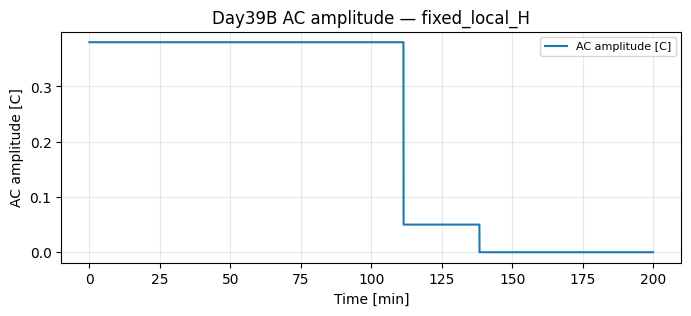

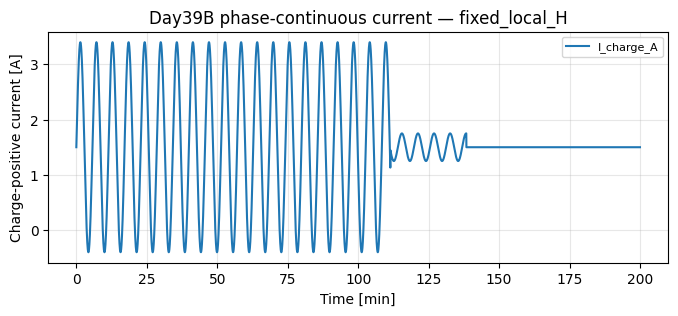

[WAVEFORM] seg_tau_fast_k1p5


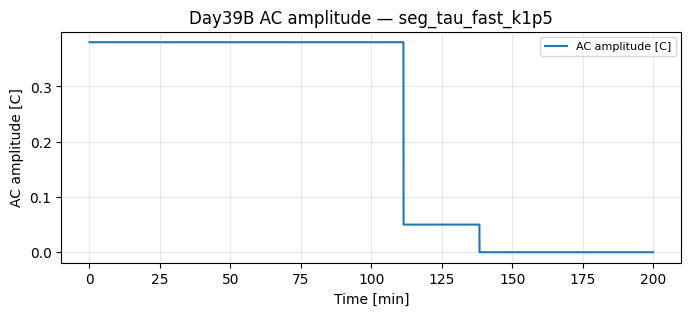

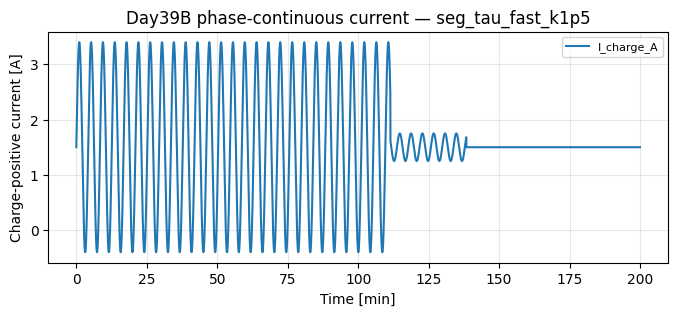

[WAVEFORM] seg_tau_slow_k1p5


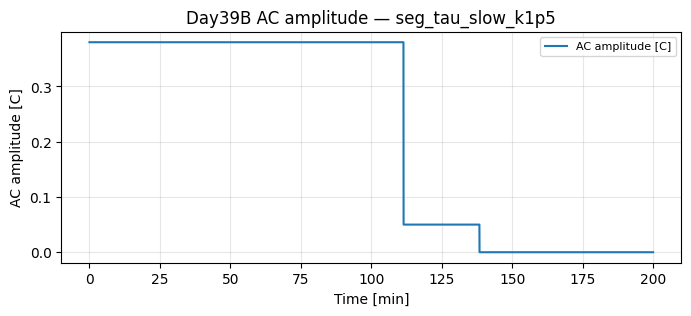

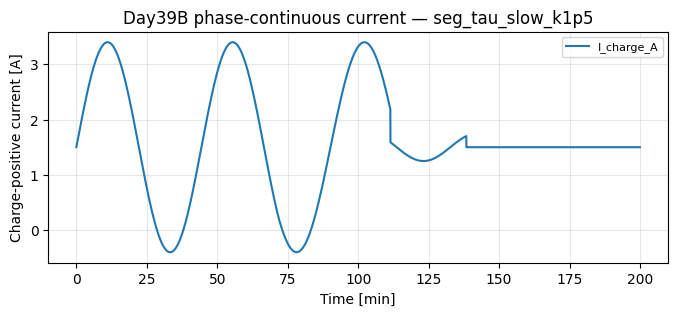

[WAVEFORM] seg_tau_fast_k1p0


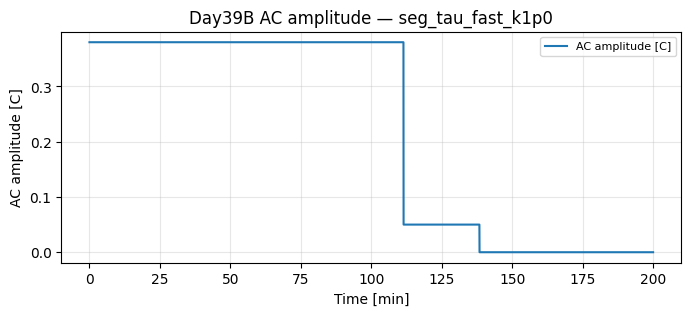

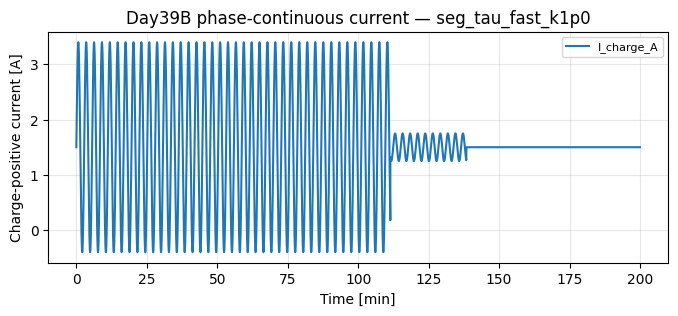

[WAVEFORM] seg_tau_fast_k3p0


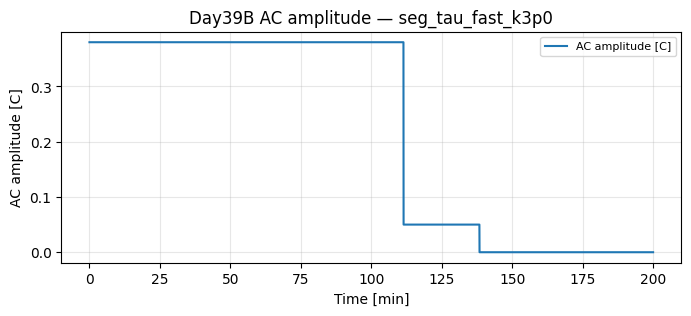

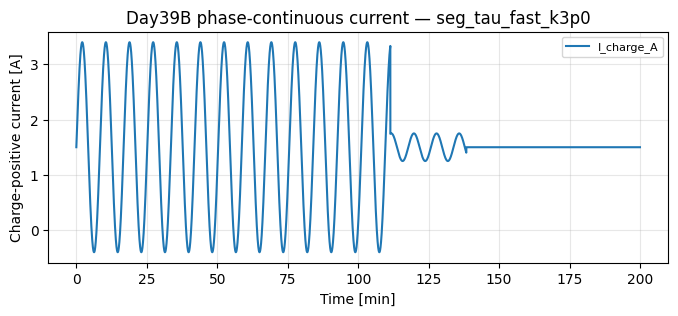

[OK] saved phase-continuous waveform timeseries: /Users/louislu/pybamm-dcac-superimposed/data/day39_phase_continuous_waveform_timeseries.csv
[OK] saved phase-continuous waveform summary: /Users/louislu/pybamm-dcac-superimposed/data/day39_phase_continuous_waveform_summary.csv


,frequency_policy_id,I_charge_min_A,I_charge_max_A,I_py_min_A,I_py_max_A,AC_C_min,AC_C_max,f_Hz_min,f_Hz_max,period_s_min,period_s_max,Q_geom_end_Ah,sign_ok,phase_monotonic,max_phase_step_rad
0,fixed_local_H,-0.400000,3.400000,-3.400000,0.400000,0.0,0.38,0.002922,0.002922,342.275253,342.275253,5.053360,True,True,0.018357
1,seg_tau_fast_k1p5,-0.400000,3.400000,-3.400000,0.400000,0.0,0.38,0.003910,0.004152,240.845277,255.760041,5.035850,True,True,0.026088
2,seg_tau_slow_k1p5,-0.400000,3.400000,-3.400000,0.400000,0.0,0.38,0.000346,0.000438,2284.412005,2887.386581,5.397670,True,True,0.002750
3,seg_tau_fast_k1p0,-0.399995,3.400000,-3.400000,0.399995,0.0,0.38,0.005865,0.006228,160.563518,170.506694,5.023484,True,True,0.039132
4,seg_tau_fast_k3p0,-0.400000,3.399999,-3.399999,0.400000,0.0,0.38,0.001955,0.002076,481.690554,511.520083,5.036806,True,True,0.013044


[OK] saved cycle coverage: /Users/louislu/pybamm-dcac-superimposed/data/day39_frequency_cycle_coverage.csv


,frequency_policy_id,segment_id,segment_role,tau_descriptor,k_factor,tau_used_s,f_Hz,period_s,segment_duration_s,n_cycles_in_segment,cycle_coverage_class
0,fixed_local_H,seg_low,early_high_AC_lowQ,tau_ref_set_fallback,1.5,36.316532,0.002922,342.275253,4313.163843,12.601448,usable_periodic_coverage
1,fixed_local_H,seg_mid,early_high_AC_midQ,tau_ref_set_fallback,1.5,36.316532,0.002922,342.275253,2372.240113,6.930796,usable_periodic_coverage
2,fixed_local_H,seg_derated,mid_low_AC_derated,tau_ref_set_fallback,1.5,36.316532,0.002922,342.275253,1617.436441,4.725543,usable_periodic_coverage
3,seg_tau_fast_k1p5,seg_low,early_high_AC_lowQ,tau_fast_s,1.5,26.698289,0.003974,251.625445,4313.163843,17.141207,usable_periodic_coverage
4,seg_tau_fast_k1p5,seg_mid,early_high_AC_midQ,tau_fast_s,1.5,27.136983,0.003910,255.760041,2372.240113,9.275257,usable_periodic_coverage
5,seg_tau_fast_k1p5,seg_derated,mid_low_AC_derated,tau_fast_s,1.5,25.554478,0.004152,240.845277,1617.436441,6.715666,usable_periodic_coverage
6,seg_tau_slow_k1p5,seg_low,early_high_AC_lowQ,tau_slow_s,1.5,282.546335,0.000376,2662.936474,4313.163843,1.619702,weak_periodic_coverage
7,seg_tau_slow_k1p5,seg_mid,early_high_AC_midQ,tau_slow_s,1.5,306.361231,0.000346,2887.386581,2372.240113,0.821587,quasi_ramp_or_insufficient_cycles
8,seg_tau_slow_k1p5,seg_derated,mid_low_AC_derated,tau_slow_s,1.5,242.383642,0.000438,2284.412005,1617.436441,0.708032,quasi_ramp_or_insufficient_cycles
9,seg_tau_fast_k1p0,seg_low,early_high_AC_lowQ,tau_fast_s,1.0,26.698289,0.005961,167.750297,4313.163843,25.711810,usable_periodic_coverage


In [14]:
# Cell 9 — Day39B waveform audit and cycle coverage（Day39B波形审计与周期覆盖）

waveform_records = []
waveform_summary_rows = []

for policy_id in frequency_policy_df["frequency_policy_id"]:
    print("[WAVEFORM]", policy_id)
    wf = build_phase_continuous_waveform(policy_id)
    waveform_records.append(wf)

    sign_ok = bool((wf["I_charge_A"].max() > 0.0) and (wf["I_py_A"].min() < 0.0))

    # Phase continuity audit: no large negative jumps; phase should be non-decreasing.
    dphi = np.diff(wf["phase_rad"].to_numpy())
    phase_monotonic = bool(np.nanmin(dphi) >= -1e-12)
    max_phase_step = float(np.nanmax(np.abs(dphi))) if len(dphi) else np.nan

    waveform_summary_rows.append({
        "frequency_policy_id": policy_id,
        "I_charge_min_A": float(wf["I_charge_A"].min()),
        "I_charge_max_A": float(wf["I_charge_A"].max()),
        "I_py_min_A": float(wf["I_py_A"].min()),
        "I_py_max_A": float(wf["I_py_A"].max()),
        "AC_C_min": float(wf["AC_C_scheduled"].min()),
        "AC_C_max": float(wf["AC_C_scheduled"].max()),
        "f_Hz_min": float(wf.loc[wf["AC_C_scheduled"] > 0, "f_Hz"].min()),
        "f_Hz_max": float(wf.loc[wf["AC_C_scheduled"] > 0, "f_Hz"].max()),
        "period_s_min": float(1.0 / wf.loc[wf["AC_C_scheduled"] > 0, "f_Hz"].max()),
        "period_s_max": float(1.0 / wf.loc[wf["AC_C_scheduled"] > 0, "f_Hz"].min()),
        "Q_geom_end_Ah": float(wf["Q_geom_Ah"].max()),
        "sign_ok": sign_ok,
        "phase_monotonic": phase_monotonic,
        "max_phase_step_rad": max_phase_step,
    })

    # Plot AC amplitude and current for quick audit.
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(wf["t_s"] / 60.0, wf["AC_C_scheduled"], label="AC amplitude [C]")
    ax.set_xlabel("Time [min]")
    ax.set_ylabel("AC amplitude [C]")
    ax.set_title(f"Day39B AC amplitude — {policy_id}")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(wf["t_s"] / 60.0, wf["I_charge_A"], label="I_charge_A")
    ax.set_xlabel("Time [min]")
    ax.set_ylabel("Charge-positive current [A]")
    ax.set_title(f"Day39B phase-continuous current — {policy_id}")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    plt.show()

day39_waveform_df = pd.concat(waveform_records, ignore_index=True)
day39_waveform_summary_df = pd.DataFrame(waveform_summary_rows)

out = DATA_DIR / "day39_phase_continuous_waveform_timeseries.csv"
day39_waveform_df.to_csv(out, index=False)

out2 = DATA_DIR / "day39_phase_continuous_waveform_summary.csv"
day39_waveform_summary_df.to_csv(out2, index=False)

print("[OK] saved phase-continuous waveform timeseries:", out)
print("[OK] saved phase-continuous waveform summary:", out2)

display(day39_waveform_summary_df)


# Cycle coverage summary already saved in frequency_segment_table_df, but add compact coverage view.
coverage_cols = [
    "frequency_policy_id",
    "segment_id",
    "segment_role",
    "tau_descriptor",
    "k_factor",
    "tau_used_s",
    "f_Hz",
    "period_s",
    "segment_duration_s",
    "n_cycles_in_segment",
    "cycle_coverage_class",
]

day39_cycle_coverage_df = frequency_segment_table_df[coverage_cols].copy()

out = DATA_DIR / "day39_frequency_cycle_coverage.csv"
day39_cycle_coverage_df.to_csv(out, index=False)

print("[OK] saved cycle coverage:", out)
display(day39_cycle_coverage_df)


## Day39C — PyBaMM evaluation of phase-continuous frequency schedules

Day39B built phase-continuous current waveforms for five frequency policies:

1. `fixed_local_H`
2. `seg_tau_fast_k1p5`
3. `seg_tau_slow_k1p5`
4. `seg_tau_fast_k1p0`
5. `seg_tau_fast_k3p0`

The waveform audit confirmed:

- `I_py_A = -I_charge_A`;
- phase is monotonic / continuous;
- `tau_fast` schedules have usable periodic coverage;
- `tau_slow` has weak or insufficient cycle coverage in some AC-on segments.

Day39C now evaluates these policies in PyBaMM and compares:

- raw timing gain;
- geometry–residual decomposition;
- negative-electrode margin;
- microstate stress;
- frequency-policy score.

This remains open-loop frequency scheduling, not MPC.

In [15]:
# Cell 10 — Day39C simulation utilities（Day39C仿真工具）

NE_SURFACE_KEY = "Negative electrode surface potential difference [V]"
NE_XAVG_KEY = "X-averaged negative electrode surface potential difference [V]"
ELYTE_C_KEY = "Electrolyte concentration [mol.m-3]"
ETA_N_KEY = "X-averaged negative electrode reaction overpotential [V]"
ETA_P_KEY = "X-averaged positive electrode reaction overpotential [V]"
NEG_AVG_STO_KEY = "Average negative particle stoichiometry"
NEG_SURF_STO_XAVG_KEY = "X-averaged negative particle surface stoichiometry"
NEG_SURF_STO_MAX_KEY = "Maximum negative particle surface stoichiometry"
NEG_SURF_STO_MIN_KEY = "Minimum negative particle surface stoichiometry"

PLATING_MARGIN_HARD_LIMIT_MV = 0.0
PLATING_MARGIN_TARGET_MV = 20.0
PLATING_MARGIN_BUFFER_MV = 50.0

def make_day39_model():
    return pybamm.lithium_ion.DFN({
        "thermal": THERMAL_MODE,
        "surface form": "false",
    })


def make_dc_reference_waveform(t_max_s=12000.0, dt_s=1.0):
    t_grid = np.arange(0.0, t_max_s + dt_s, dt_s)
    i_charge = np.full_like(t_grid, I_DC_A, dtype=float)
    i_py = -i_charge
    q_geom = cumulative_trapezoid_np(i_charge, t_grid) / 3600.0

    return pd.DataFrame({
        "frequency_policy_id": "DC03_reference",
        "t_s": t_grid,
        "AC_C_scheduled": np.zeros_like(t_grid, dtype=float),
        "f_Hz": np.zeros_like(t_grid, dtype=float),
        "omega_rad_s": np.zeros_like(t_grid, dtype=float),
        "phase_rad": np.zeros_like(t_grid, dtype=float),
        "I_charge_A": i_charge,
        "I_py_A": i_py,
        "Q_geom_Ah": q_geom,
    })


def make_parameter_values_from_waveform(waveform_df):
    pv = pybamm.ParameterValues(PRIMARY_PARAMETER_SET)

    current_interpolant = pybamm.Interpolant(
        waveform_df["t_s"].to_numpy(),
        waveform_df["I_py_A"].to_numpy(),
        pybamm.t,
        interpolator="linear",
    )

    pv.update({"Current function [A]": current_interpolant}, check_already_exists=False)

    return pv


def extract_basic_timeseries(sol):
    t_s = np.asarray(sol.t, dtype=float)
    I_py_A = np.asarray(sol["Current [A]"](t_s), dtype=float).reshape(-1)
    V_terminal_V = np.asarray(sol["Terminal voltage [V]"](t_s), dtype=float).reshape(-1)

    I_charge_A = -I_py_A
    Q_net_Ah = cumulative_trapezoid_np(I_charge_A, t_s) / 3600.0

    return pd.DataFrame({
        "t_s": t_s,
        "I_py_A": I_py_A,
        "I_charge_A": I_charge_A,
        "V_terminal_V": V_terminal_V,
        "Q_net_Ah": Q_net_Ah,
    })


def run_day39_waveform(policy_id, waveform_df, initial_soc=INITIAL_SOC, max_time_s=24000, n_eval=5000):
    model = make_day39_model()
    pv = make_parameter_values_from_waveform(waveform_df)

    sim = pybamm.Simulation(model, parameter_values=pv)
    t_eval = np.linspace(0.0, max_time_s, n_eval)
    sol = sim.solve(t_eval=t_eval, initial_soc=initial_soc)
    ts = extract_basic_timeseries(sol)

    return {
        "policy_id": policy_id,
        "sim": sim,
        "sol": sol,
        "ts": ts,
        "geom": waveform_df.copy(),
    }


def reduce_to_timeseries(arr, t_s, reducer="mean"):
    arr = np.asarray(arr, dtype=float)
    t_s = np.asarray(t_s, dtype=float)
    n_t = len(t_s)

    if arr.ndim == 0:
        return np.full(n_t, float(arr))

    if arr.ndim == 1:
        if arr.shape[0] == n_t:
            return arr
        return np.full(n_t, np.nanmean(arr))

    if arr.shape[-1] == n_t:
        flat = arr.reshape(-1, n_t)
        axis = 0
    elif arr.shape[0] == n_t:
        flat = arr.reshape(n_t, -1)
        axis = 1
    else:
        raise ValueError(f"Cannot identify time axis: arr.shape={arr.shape}, n_t={n_t}")

    if reducer == "min":
        return np.nanmin(flat, axis=axis)
    if reducer == "max":
        return np.nanmax(flat, axis=axis)
    if reducer == "mean":
        return np.nanmean(flat, axis=axis)

    raise ValueError(reducer)


def safe_extract(sol, key, t_s, reducer="mean"):
    try:
        return reduce_to_timeseries(sol[key](t_s), t_s, reducer=reducer)
    except Exception:
        return np.full(len(t_s), np.nan)


def classify_margin_mV(u_mV):
    if pd.isna(u_mV):
        return "unresolved"
    if u_mV <= PLATING_MARGIN_HARD_LIMIT_MV:
        return "risk_flag"
    if u_mV <= PLATING_MARGIN_BUFFER_MV:
        return "near_boundary"
    return "safe_margin"

print("[OK] Day39C simulation utilities ready")

[OK] Day39C simulation utilities ready


In [16]:
# Cell 11 — Run Day39C frequency-policy simulations（运行Day39C频率策略仿真）

# Build waveform objects.
waveform_map = {"DC03_reference": make_dc_reference_waveform()}

for policy_id in frequency_policy_df["frequency_policy_id"]:
    wf = day39_waveform_df[day39_waveform_df["frequency_policy_id"] == policy_id].copy()
    waveform_map[policy_id] = wf

solutions = {}
run_rows = []

for policy_id, wf in waveform_map.items():
    print(f"\n[RUN] {policy_id}")

    try:
        result = run_day39_waveform(policy_id, wf)
        solutions[policy_id] = result
        ts = result["ts"]

        run_rows.append({
            "frequency_policy_id": policy_id,
            "status": "ok",
            "termination": str(result["sol"].termination),
            "t_end_s": float(ts["t_s"].iloc[-1]),
            "t_end_min": float(ts["t_s"].iloc[-1] / 60.0),
            "Q_end_Ah": float(ts["Q_net_Ah"].iloc[-1]),
            "V_end_V": float(ts["V_terminal_V"].iloc[-1]),
            "I_charge_min_A": float(ts["I_charge_A"].min()),
            "I_charge_max_A": float(ts["I_charge_A"].max()),
            "error": "",
        })

        print("[OK]", policy_id, "| termination:", result["sol"].termination)

    except Exception as e:
        run_rows.append({
            "frequency_policy_id": policy_id,
            "status": "failed",
            "termination": "",
            "t_end_s": np.nan,
            "t_end_min": np.nan,
            "Q_end_Ah": np.nan,
            "V_end_V": np.nan,
            "I_charge_min_A": np.nan,
            "I_charge_max_A": np.nan,
            "error": repr(e),
        })
        print("[FAILED]", policy_id, repr(e))

day39_run_summary_df = pd.DataFrame(run_rows)

out = DATA_DIR / "day39_frequency_policy_run_summary.csv"
day39_run_summary_df.to_csv(out, index=False)

print("[OK] saved Day39 run summary:", out)
display(day39_run_summary_df)

if (day39_run_summary_df["status"] != "ok").any():
    print("[WARN] Some simulations failed. Inspect before continuing.")
else:
    print("[OK] all Day39 frequency-policy simulations completed.")


[RUN] DC03_reference
[OK] DC03_reference | termination: event: Maximum voltage [V]

[RUN] fixed_local_H
[OK] fixed_local_H | termination: event: Maximum voltage [V]

[RUN] seg_tau_fast_k1p5
[OK] seg_tau_fast_k1p5 | termination: event: Maximum voltage [V]

[RUN] seg_tau_slow_k1p5
[OK] seg_tau_slow_k1p5 | termination: event: Maximum voltage [V]

[RUN] seg_tau_fast_k1p0
[OK] seg_tau_fast_k1p0 | termination: event: Maximum voltage [V]

[RUN] seg_tau_fast_k3p0
[OK] seg_tau_fast_k3p0 | termination: event: Maximum voltage [V]
[OK] saved Day39 run summary: /Users/louislu/pybamm-dcac-superimposed/data/day39_frequency_policy_run_summary.csv


,frequency_policy_id,status,termination,t_end_s,t_end_min,Q_end_Ah,V_end_V,I_charge_min_A,I_charge_max_A,error
0,DC03_reference,ok,event: Maximum voltage [V],10782.909607,179.715160,4.492879,4.2,1.500000,1.500000,
1,fixed_local_H,ok,event: Maximum voltage [V],10655.176324,177.586272,4.493002,4.2,-0.399987,3.399991,
2,seg_tau_fast_k1p5,ok,event: Maximum voltage [V],10693.455308,178.224255,4.491437,4.2,-0.399993,3.399949,
3,seg_tau_slow_k1p5,ok,event: Maximum voltage [V],9822.255847,163.704264,4.490276,4.2,-0.399999,3.399998,
4,seg_tau_fast_k1p0,ok,event: Maximum voltage [V],10725.831229,178.763854,4.492534,4.2,-0.399977,3.399985,
5,seg_tau_fast_k3p0,ok,event: Maximum voltage [V],10693.213742,178.220229,4.492310,4.2,-0.399990,3.399997,


[OK] all Day39 frequency-policy simulations completed.


In [17]:
# Cell 12 — Extract margin and microstate summaries（提取余量与微观状态摘要）

state_ts_map = {}
state_rows = []

for policy_id, obj in solutions.items():
    print("[EXTRACT]", policy_id)

    sol = obj["sol"]
    ts = obj["ts"].copy()
    t_s = ts["t_s"].to_numpy()

    ne_surface = sol[NE_SURFACE_KEY](t_s)
    ts["U_NE_min_V"] = reduce_to_timeseries(ne_surface, t_s, reducer="min")
    ts["U_NE_min_mV"] = ts["U_NE_min_V"] * 1000.0
    ts["U_NE_xavg_V"] = safe_extract(sol, NE_XAVG_KEY, t_s, reducer="mean")

    c_e = sol[ELYTE_C_KEY](t_s)
    ts["c_e_min_molm3"] = reduce_to_timeseries(c_e, t_s, reducer="min")
    ts["c_e_max_molm3"] = reduce_to_timeseries(c_e, t_s, reducer="max")
    ts["c_e_range_molm3"] = ts["c_e_max_molm3"] - ts["c_e_min_molm3"]

    ts["eta_n_V"] = safe_extract(sol, ETA_N_KEY, t_s, reducer="mean")
    ts["neg_surface_sto_xavg"] = safe_extract(sol, NEG_SURF_STO_XAVG_KEY, t_s, reducer="mean")
    ts["neg_surface_sto_max"] = safe_extract(sol, NEG_SURF_STO_MAX_KEY, t_s, reducer="mean")
    ts["neg_surface_sto_min"] = safe_extract(sol, NEG_SURF_STO_MIN_KEY, t_s, reducer="mean")
    ts["neg_surface_sto_range"] = ts["neg_surface_sto_max"] - ts["neg_surface_sto_min"]

    state_ts_map[policy_id] = ts

    idx_min = int(ts["U_NE_min_V"].idxmin())
    r = ts.loc[idx_min]

    state_rows.append({
        "frequency_policy_id": policy_id,
        "min_U_NE_mV": float(r["U_NE_min_mV"]),
        "margin_class": classify_margin_mV(float(r["U_NE_min_mV"])),
        "fraction_time_below_0mV": float((ts["U_NE_min_mV"] <= PLATING_MARGIN_HARD_LIMIT_MV).mean()),
        "fraction_time_below_50mV": float((ts["U_NE_min_mV"] <= PLATING_MARGIN_BUFFER_MV).mean()),
        "Q_at_min_U_NE_Ah": float(r["Q_net_Ah"]),
        "t_at_min_U_NE_s": float(r["t_s"]),
        "I_charge_at_min_U_NE_A": float(r["I_charge_A"]),
        "I_charge_peak_observed_A": float(ts["I_charge_A"].max()),
        "V_terminal_at_min_U_NE_V": float(r["V_terminal_V"]),
        "max_c_e_range_molm3": float(ts["c_e_range_molm3"].max()),
        "c_e_range_at_min_U_NE_molm3": float(r["c_e_range_molm3"]),
        "max_neg_surface_sto_range": float(np.nanmax(ts["neg_surface_sto_range"])),
        "surface_range_at_min_U_NE": float(r["neg_surface_sto_range"]),
        "eta_n_at_min_U_NE_V": float(r["eta_n_V"]),
    })

day39_margin_microstate_summary_df = pd.DataFrame(state_rows)

# Normalize to DC reference.
dc_state = day39_margin_microstate_summary_df[
    day39_margin_microstate_summary_df["frequency_policy_id"] == "DC03_reference"
].iloc[0]

day39_margin_microstate_summary_df["max_c_e_range_vs_DC"] = (
    day39_margin_microstate_summary_df["max_c_e_range_molm3"] / dc_state["max_c_e_range_molm3"]
)
day39_margin_microstate_summary_df["surface_range_at_min_vs_DC"] = (
    day39_margin_microstate_summary_df["surface_range_at_min_U_NE"] / dc_state["surface_range_at_min_U_NE"]
)
day39_margin_microstate_summary_df["abs_eta_n_at_min_vs_DC"] = (
    day39_margin_microstate_summary_df["eta_n_at_min_U_NE_V"].abs() / abs(dc_state["eta_n_at_min_U_NE_V"])
)

out = DATA_DIR / "day39_frequency_policy_margin_microstate_summary.csv"
day39_margin_microstate_summary_df.to_csv(out, index=False)

print("[OK] saved margin/microstate summary:", out)
display(day39_margin_microstate_summary_df)

[EXTRACT] DC03_reference
[EXTRACT] fixed_local_H
[EXTRACT] seg_tau_fast_k1p5
[EXTRACT] seg_tau_slow_k1p5
[EXTRACT] seg_tau_fast_k1p0
[EXTRACT] seg_tau_fast_k3p0
[OK] saved margin/microstate summary: /Users/louislu/pybamm-dcac-superimposed/data/day39_frequency_policy_margin_microstate_summary.csv


,frequency_policy_id,min_U_NE_mV,margin_class,fraction_time_below_0mV,fraction_time_below_50mV,Q_at_min_U_NE_Ah,t_at_min_U_NE_s,I_charge_at_min_U_NE_A,I_charge_peak_observed_A,V_terminal_at_min_U_NE_V,max_c_e_range_molm3,c_e_range_at_min_U_NE_molm3,max_neg_surface_sto_range,surface_range_at_min_U_NE,eta_n_at_min_U_NE_V,max_c_e_range_vs_DC,surface_range_at_min_vs_DC,abs_eta_n_at_min_vs_DC
0,DC03_reference,37.280562,near_boundary,0.0,0.219837,4.492879,10782.909607,1.500000,1.500000,4.20000,377.868423,354.118549,0.116717,0.116717,-0.045310,1.000000,1.000000,1.000000
1,fixed_local_H,37.151324,near_boundary,0.0,0.211080,4.493002,10655.176324,1.500000,3.399991,4.20000,728.223132,354.928181,0.133279,0.124003,-0.045405,1.927187,1.062431,1.002093
2,seg_tau_fast_k1p5,37.170648,near_boundary,0.0,0.195674,4.491437,10693.455308,1.500000,3.399949,4.20000,701.497261,354.808436,0.130037,0.122886,-0.045391,1.856459,1.052863,1.001781
3,seg_tau_slow_k1p5,30.716537,near_boundary,0.0,0.277650,2.942640,6323.789889,3.238669,3.399998,4.03695,787.002051,774.268491,0.148577,0.139093,-0.067395,2.082741,1.191716,1.487416
4,seg_tau_fast_k1p0,37.196464,near_boundary,0.0,0.170313,4.492534,10725.831229,1.500000,3.399985,4.20000,644.836369,354.648851,0.125796,0.121421,-0.045372,1.706510,1.040305,1.001362
5,seg_tau_fast_k3p0,37.165323,near_boundary,0.0,0.228884,4.492310,10693.213742,1.500000,3.399997,4.20000,740.904272,354.848819,0.134870,0.123055,-0.045395,1.960747,1.054306,1.001875


In [18]:
# Cell 13 — Equal-Q timing and geometry-residual for frequency policies（频率策略等Q时间与几何-残差）

def first_passage_time(t_s, q_Ah, q_target_Ah):
    t_s = np.asarray(t_s, dtype=float)
    q_Ah = np.asarray(q_Ah, dtype=float)

    hit = np.where(q_Ah >= q_target_Ah)[0]
    if len(hit) == 0:
        return np.nan

    i = int(hit[0])
    if i == 0:
        return float(t_s[0])

    q0, q1 = q_Ah[i - 1], q_Ah[i]
    t0, t1 = t_s[i - 1], t_s[i]

    if q1 == q0:
        return float(t1)

    frac = (q_target_Ah - q0) / (q1 - q0)
    return float(t0 + frac * (t1 - t0))


def first_passage_from_geom_df(geom_df, q_target_Ah):
    return first_passage_time(
        geom_df["t_s"].to_numpy(),
        geom_df["Q_geom_Ah"].to_numpy(),
        q_target_Ah,
    )


dc_ts = state_ts_map["DC03_reference"]
dc_geom = solutions["DC03_reference"]["geom"]

q_end_all = min(float(ts["Q_net_Ah"].max()) for pid, ts in state_ts_map.items())
q_grid = np.linspace(0.2, 0.95 * q_end_all, 100)

eq_rows = []

for policy_id, ts in state_ts_map.items():
    if policy_id == "DC03_reference":
        continue

    geom = solutions[policy_id]["geom"]

    for q in q_grid:
        t_dc = first_passage_time(dc_ts["t_s"], dc_ts["Q_net_Ah"], q)
        t_policy = first_passage_time(ts["t_s"], ts["Q_net_Ah"], q)
        t_dc_geom = first_passage_from_geom_df(dc_geom, q)
        t_policy_geom = first_passage_from_geom_df(geom, q)

        eq_rows.append({
            "frequency_policy_id": policy_id,
            "Q_Ah": float(q),
            "delta_t_raw_s": t_dc - t_policy,
            "delta_t_geom_s": t_dc_geom - t_policy_geom,
            "delta_t_resid_s": (t_dc - t_policy) - (t_dc_geom - t_policy_geom),
        })

day39_equalq_df = pd.DataFrame(eq_rows)

out = DATA_DIR / "day39_frequency_policy_equalQ_timing_curves.csv"
day39_equalq_df.to_csv(out, index=False)

day39_timing_summary_df = (
    day39_equalq_df
    .groupby("frequency_policy_id", as_index=False)
    .agg(
        delta_t_raw_mean_s=("delta_t_raw_s", "mean"),
        delta_t_raw_min_s=("delta_t_raw_s", "min"),
        delta_t_raw_max_s=("delta_t_raw_s", "max"),
        delta_t_geom_mean_s=("delta_t_geom_s", "mean"),
        delta_t_resid_mean_s=("delta_t_resid_s", "mean"),
        resid_abs_mean_s=("delta_t_resid_s", lambda x: np.nanmean(np.abs(x))),
        resid_max_abs_s=("delta_t_resid_s", lambda x: np.nanmax(np.abs(x))),
        resid_positive_fraction=("delta_t_resid_s", lambda x: np.nanmean(np.asarray(x) > 0.0)),
    )
)

def classify_resid(row):
    raw = abs(row["delta_t_raw_mean_s"])
    if raw < 1:
        return "near_zero_or_unresolved"

    ratio = row["resid_abs_mean_s"] / raw

    if (row["delta_t_resid_mean_s"] > 5.0) and (row["resid_positive_fraction"] >= 0.75):
        return "candidate_positive_residual"

    if ratio < 0.05:
        return "geometry_dominated"
    if ratio < 0.20:
        return "mostly_geometry_small_residual"
    return "residual_non_negligible"

day39_timing_summary_df["dt_resid_class"] = day39_timing_summary_df.apply(classify_resid, axis=1)

out = DATA_DIR / "day39_frequency_policy_timing_geom_resid_summary.csv"
day39_timing_summary_df.to_csv(out, index=False)

print("[OK] saved equal-Q timing curves:", DATA_DIR / "day39_frequency_policy_equalQ_timing_curves.csv")
print("[OK] saved timing summary:", out)
display(day39_timing_summary_df)

[OK] saved equal-Q timing curves: /Users/louislu/pybamm-dcac-superimposed/data/day39_frequency_policy_equalQ_timing_curves.csv
[OK] saved timing summary: /Users/louislu/pybamm-dcac-superimposed/data/day39_frequency_policy_timing_geom_resid_summary.csv


,frequency_policy_id,delta_t_raw_mean_s,delta_t_raw_min_s,delta_t_raw_max_s,delta_t_geom_mean_s,delta_t_resid_mean_s,resid_abs_mean_s,resid_max_abs_s,resid_positive_fraction,dt_resid_class
0,fixed_local_H,91.812842,0.052397,137.960155,91.834118,-0.021275,0.021316,0.216483,0.01,geometry_dominated
1,seg_tau_fast_k1p0,42.228392,-0.516255,67.713793,42.295261,-0.066869,0.066869,0.191235,0.00,geometry_dominated
2,seg_tau_fast_k1p5,66.059736,-0.001676,102.646856,66.090481,-0.030745,0.030745,0.199974,0.00,geometry_dominated
3,seg_tau_fast_k3p0,96.522497,-2.519357,202.945686,96.526965,-0.004467,0.004575,0.018836,0.02,geometry_dominated
4,seg_tau_slow_k1p5,662.488072,-77.465772,1070.257228,662.488796,-0.000724,0.000791,0.006271,0.13,geometry_dominated


In [19]:
# Cell 14 — Frequency policy ledger and first verdict（频率策略账本与初步判定）

ledger_df = (
    frequency_policy_df
    .merge(day39_waveform_summary_df, on="frequency_policy_id", how="left")
    .merge(day39_margin_microstate_summary_df, on="frequency_policy_id", how="left")
    .merge(day39_timing_summary_df, on="frequency_policy_id", how="left")
)

# Add cycle coverage diagnostics.
coverage_summary_df = (
    day39_cycle_coverage_df
    .groupby("frequency_policy_id", as_index=False)
    .agg(
        min_n_cycles=("n_cycles_in_segment", "min"),
        mean_n_cycles=("n_cycles_in_segment", "mean"),
        n_insufficient_segments=("cycle_coverage_class", lambda x: int(np.sum(np.asarray(x) == "quasi_ramp_or_insufficient_cycles"))),
        n_weak_segments=("cycle_coverage_class", lambda x: int(np.sum(np.asarray(x) == "weak_periodic_coverage"))),
    )
)

ledger_df = ledger_df.merge(coverage_summary_df, on="frequency_policy_id", how="left")

# Score. Same spirit as Day38 strict margin, but add cycle-coverage penalty.
GAIN_REFERENCE_S = 95.0

ledger_df["gain_norm"] = np.clip(ledger_df["delta_t_raw_mean_s"] / GAIN_REFERENCE_S, 0.0, 2.0)
ledger_df["margin_reward"] = np.clip(ledger_df["min_U_NE_mV"] / PLATING_MARGIN_TARGET_MV, -1.0, 1.0)
ledger_df["low_margin_penalty"] = np.where(
    ledger_df["min_U_NE_mV"] > 0,
    np.maximum(0.0, (PLATING_MARGIN_TARGET_MV - ledger_df["min_U_NE_mV"]) / PLATING_MARGIN_TARGET_MV) ** 2,
    2.0,
)
ledger_df["transport_penalty"] = np.clip((ledger_df["max_c_e_range_vs_DC"] - 1.0) / 2.0, 0.0, 2.0)
ledger_df["surface_penalty"] = np.clip((ledger_df["surface_range_at_min_vs_DC"] - 1.0), 0.0, 2.0)
ledger_df["eta_penalty"] = np.clip((ledger_df["abs_eta_n_at_min_vs_DC"] - 1.0) / 2.0, 0.0, 2.0)
ledger_df["hard_margin_penalty"] = (ledger_df["min_U_NE_mV"] <= 0.0).astype(float) * 3.0
ledger_df["cycle_coverage_penalty"] = (
    0.15 * ledger_df["n_weak_segments"].fillna(0)
    + 0.40 * ledger_df["n_insufficient_segments"].fillna(0)
)

ledger_df["frequency_policy_score"] = (
    0.45 * ledger_df["gain_norm"]
    + 0.25 * ledger_df["margin_reward"]
    - 0.35 * ledger_df["low_margin_penalty"]
    - 0.10 * ledger_df["transport_penalty"]
    - 0.05 * ledger_df["surface_penalty"]
    - 0.05 * ledger_df["eta_penalty"]
    - ledger_df["hard_margin_penalty"]
    - ledger_df["cycle_coverage_penalty"]
)

def classify_frequency_policy(row):
    if row["min_U_NE_mV"] <= 0:
        return "reject_hard_margin"
    if row["n_insufficient_segments"] > 0:
        return "diagnostic_only_insufficient_cycle_coverage"
    if row["min_U_NE_mV"] < PLATING_MARGIN_TARGET_MV:
        return "low_margin_candidate"
    if row["delta_t_raw_mean_s"] >= row["delta_t_raw_mean_s_fixed_ref"] - 5 if "delta_t_raw_mean_s_fixed_ref" in row else False:
        return "candidate"
    return "candidate"

# Add comparison to fixed baseline.
fixed_ref = ledger_df[ledger_df["frequency_policy_id"] == "fixed_local_H"].iloc[0]
ledger_df["delta_raw_vs_fixed_s"] = ledger_df["delta_t_raw_mean_s"] - fixed_ref["delta_t_raw_mean_s"]
ledger_df["delta_min_U_NE_vs_fixed_mV"] = ledger_df["min_U_NE_mV"] - fixed_ref["min_U_NE_mV"]
ledger_df["delta_c_e_range_vs_fixed"] = ledger_df["max_c_e_range_vs_DC"] - fixed_ref["max_c_e_range_vs_DC"]

def classify_frequency_policy_final(row):
    if row["min_U_NE_mV"] <= 0:
        return "reject_hard_margin"
    if row["n_insufficient_segments"] > 0:
        return "diagnostic_only_insufficient_cycle_coverage"
    if row["min_U_NE_mV"] < PLATING_MARGIN_TARGET_MV:
        return "low_margin_candidate"
    if row["delta_raw_vs_fixed_s"] >= -5 and row["delta_min_U_NE_vs_fixed_mV"] >= -5:
        return "candidate_comparable_to_fixed"
    if row["delta_raw_vs_fixed_s"] > 0:
        return "candidate_gain_improvement_with_tradeoff"
    return "candidate_but_no_clear_gain_advantage"

ledger_df["frequency_policy_verdict"] = ledger_df.apply(classify_frequency_policy_final, axis=1)

out = DATA_DIR / "day39_frequency_policy_ledger.csv"
ledger_df.to_csv(out, index=False)

print("[OK] saved frequency policy ledger:", out)

display_cols = [
    "frequency_policy_id",
    "frequency_mode",
    "tau_descriptor",
    "k_factor",
    "delta_t_raw_mean_s",
    "delta_t_geom_mean_s",
    "delta_t_resid_mean_s",
    "dt_resid_class",
    "min_U_NE_mV",
    "fraction_time_below_0mV",
    "max_c_e_range_vs_DC",
    "surface_range_at_min_vs_DC",
    "min_n_cycles",
    "n_weak_segments",
    "n_insufficient_segments",
    "delta_raw_vs_fixed_s",
    "delta_min_U_NE_vs_fixed_mV",
    "frequency_policy_score",
    "frequency_policy_verdict",
]

display(ledger_df[display_cols].sort_values("frequency_policy_score", ascending=False))

[OK] saved frequency policy ledger: /Users/louislu/pybamm-dcac-superimposed/data/day39_frequency_policy_ledger.csv


,frequency_policy_id,frequency_mode,tau_descriptor,k_factor,delta_t_raw_mean_s,delta_t_geom_mean_s,delta_t_resid_mean_s,dt_resid_class,min_U_NE_mV,fraction_time_below_0mV,max_c_e_range_vs_DC,surface_range_at_min_vs_DC,min_n_cycles,n_weak_segments,n_insufficient_segments,delta_raw_vs_fixed_s,delta_min_U_NE_vs_fixed_mV,frequency_policy_score,frequency_policy_verdict
4,seg_tau_fast_k3p0,segmented_tau_rebased,tau_fast_s,3.0,96.522497,96.526965,-0.004467,geometry_dominated,37.165323,0.0,1.960747,1.054306,3.357833,0,0,4.709655,0.014000,0.656412,candidate_comparable_to_fixed
0,fixed_local_H,fixed_global_tau_ref,tau_ref_set_fallback,1.5,91.812842,91.834118,-0.021275,geometry_dominated,37.151324,0.0,1.927187,1.062431,4.725543,0,0,0.000000,0.000000,0.635370,candidate_comparable_to_fixed
1,seg_tau_fast_k1p5,segmented_tau_rebased,tau_fast_s,1.5,66.059736,66.090481,-0.030745,geometry_dominated,37.170648,0.0,1.856459,1.052863,6.715666,0,0,-25.753106,0.019324,0.517404,candidate_but_no_clear_gain_advantage
3,seg_tau_fast_k1p0,segmented_tau_rebased,tau_fast_s,1.0,42.228392,42.295261,-0.066869,geometry_dominated,37.196464,0.0,1.706510,1.040305,10.073499,0,0,-49.584450,0.045140,0.412654,candidate_but_no_clear_gain_advantage
2,seg_tau_slow_k1p5,segmented_tau_rebased,tau_slow_s,1.5,662.488072,662.488796,-0.000724,geometry_dominated,30.716537,0.0,2.082741,1.191716,0.708032,1,2,570.675229,-6.434787,0.124092,diagnostic_only_insufficient_cycle_coverage


In [20]:
# Cell 15 — Day39 final synthesis table（Day39最终综合表）

final_df = ledger_df.copy()

def recommendation_class_day39(row):
    pid = row["frequency_policy_id"]

    if pid == "seg_tau_fast_k3p0":
        return "primary_frequency_scheduled_candidate"
    if pid == "fixed_local_H":
        return "fixed_frequency_baseline"
    if pid == "seg_tau_fast_k1p5":
        return "lower_stress_but_lower_gain_candidate"
    if pid == "seg_tau_fast_k1p0":
        return "too_fast_low_gain_candidate"
    if pid == "seg_tau_slow_k1p5":
        return "slow_tail_diagnostic_only"
    return "unclassified"


def recommendation_rationale_day39(row):
    pid = row["frequency_policy_id"]

    if pid == "seg_tau_fast_k3p0":
        return (
            "Best tested frequency-scheduled candidate under isothermal electrochemical-margin criteria. "
            "Uses the local tau_fast descriptor with k=3.0, improves raw timing relative to fixed_local_H, "
            "preserves U_NE margin, and keeps usable periodic cycle coverage."
        )

    if pid == "fixed_local_H":
        return (
            "Strong Day38 fixed-frequency baseline. Remains a valid reference for amplitude/window scheduling."
        )

    if pid == "seg_tau_fast_k1p5":
        return (
            "Valid periodic tau_fast frequency schedule, but raw timing gain drops substantially relative to fixed_local_H. "
            "May be useful as a lower-stress diagnostic rather than a primary candidate."
        )

    if pid == "seg_tau_fast_k1p0":
        return (
            "Fastest tested tau_fast forcing with adequate cycle coverage, but raw timing gain drops strongly. "
            "Not preferred for the current gain-margin target."
        )

    if pid == "seg_tau_slow_k1p5":
        return (
            "Slow-tail tau schedule produces very large raw timing gain but lacks periodic cycle coverage in key segments. "
            "It is diagnostic only and should not be treated as a valid periodic AC candidate."
        )

    return "No rationale assigned."

final_df["day39_recommendation_class"] = final_df.apply(recommendation_class_day39, axis=1)
final_df["day39_recommendation_rationale"] = final_df.apply(recommendation_rationale_day39, axis=1)

recommendation_order = {
    "primary_frequency_scheduled_candidate": 0,
    "fixed_frequency_baseline": 1,
    "lower_stress_but_lower_gain_candidate": 2,
    "too_fast_low_gain_candidate": 3,
    "slow_tail_diagnostic_only": 4,
    "unclassified": 99,
}

final_df["day39_recommendation_order"] = (
    final_df["day39_recommendation_class"].map(recommendation_order).fillna(99)
)

day39_final_synthesis_df = final_df.sort_values(
    ["day39_recommendation_order", "frequency_policy_score"],
    ascending=[True, False],
).reset_index(drop=True)

out = DATA_DIR / "day39_final_frequency_policy_synthesis.csv"
day39_final_synthesis_df.to_csv(out, index=False)

print("[OK] saved Day39 final frequency policy synthesis:", out)

display_cols = [
    "frequency_policy_id",
    "day39_recommendation_class",
    "frequency_mode",
    "tau_descriptor",
    "k_factor",
    "delta_t_raw_mean_s",
    "delta_t_geom_mean_s",
    "delta_t_resid_mean_s",
    "dt_resid_class",
    "min_U_NE_mV",
    "fraction_time_below_0mV",
    "max_c_e_range_vs_DC",
    "surface_range_at_min_vs_DC",
    "abs_eta_n_at_min_vs_DC",
    "min_n_cycles",
    "n_weak_segments",
    "n_insufficient_segments",
    "delta_raw_vs_fixed_s",
    "delta_min_U_NE_vs_fixed_mV",
    "frequency_policy_score",
    "frequency_policy_verdict",
    "day39_recommendation_rationale",
]

display(day39_final_synthesis_df[display_cols])


# Recommended candidates for follow-up thermal audit.
day39_recommended_for_thermal_df = day39_final_synthesis_df[
    day39_final_synthesis_df["frequency_policy_id"].isin([
        "DC03_reference",
        "fixed_local_H",
        "seg_tau_fast_k3p0",
        "seg_tau_fast_k1p5",
        "seg_tau_slow_k1p5",
    ])
].copy()

# DC reference is not in ledger_df because ledger only has non-DC policies.
# Add a minimal reference row manually for Day40 planning.
dc_thermal_reference_row = {
    "frequency_policy_id": "DC03_reference",
    "day39_recommendation_class": "dc_reference_for_thermal_audit",
    "frequency_mode": "dc_reference",
    "tau_descriptor": "not_applicable",
    "k_factor": np.nan,
    "delta_t_raw_mean_s": 0.0,
    "min_U_NE_mV": float(day39_margin_microstate_summary_df.loc[
        day39_margin_microstate_summary_df["frequency_policy_id"] == "DC03_reference",
        "min_U_NE_mV"
    ].iloc[0]),
    "max_c_e_range_vs_DC": 1.0,
    "day39_recommendation_rationale": "Pure DC reference for Day40 thermal comparison.",
}

day39_followup_rows = [dc_thermal_reference_row]

for _, row in day39_final_synthesis_df.iterrows():
    if row["frequency_policy_id"] in [
        "fixed_local_H",
        "seg_tau_fast_k3p0",
        "seg_tau_fast_k1p5",
        "seg_tau_slow_k1p5",
    ]:
        day39_followup_rows.append({
            "frequency_policy_id": row["frequency_policy_id"],
            "day39_recommendation_class": row["day39_recommendation_class"],
            "frequency_mode": row["frequency_mode"],
            "tau_descriptor": row["tau_descriptor"],
            "k_factor": row["k_factor"],
            "delta_t_raw_mean_s": row["delta_t_raw_mean_s"],
            "min_U_NE_mV": row["min_U_NE_mV"],
            "max_c_e_range_vs_DC": row["max_c_e_range_vs_DC"],
            "day39_recommendation_rationale": row["day39_recommendation_rationale"],
        })

day39_recommended_for_thermal_df = pd.DataFrame(day39_followup_rows)

out = DATA_DIR / "day39_recommended_candidates_for_day40_thermal_audit.csv"
day39_recommended_for_thermal_df.to_csv(out, index=False)

print("[OK] saved Day39 recommended candidates for Day40 thermal audit:", out)
display(day39_recommended_for_thermal_df)


# Final claim / boundary synthesis.
day39_claim_rows = [
    {
        "claim": "Parameter-set-specific τ2 map was extracted",
        "evidence": "Chen2020 / DFN pulse-rest fits produced high-quality bi-exponential fits at qfrac 0.20, 0.40, 0.60, 0.72, and 0.85.",
        "verdict": "supported",
        "boundary": "τ descriptors are parameter-set-specific and should not be transferred to other cells or parameter sets without re-extraction.",
    },
    {
        "claim": "τ_fast and τ_slow are interchangeable frequency descriptors",
        "evidence": "τ_fast≈25–27 s and τ_slow≈242–306 s differ by nearly an order of magnitude; τ_slow has insufficient cycle coverage in key AC-on segments.",
        "verdict": "not_supported",
        "boundary": "τ_slow remains diagnostic; τ_fast is the viable periodic forcing descriptor in Day39.",
    },
    {
        "claim": "seg_tau_fast_k3p0 improves fixed_local_H under isothermal electrochemical-margin criteria",
        "evidence": "seg_tau_fast_k3p0 increases raw Δt by about 4.7 s relative to fixed_local_H while preserving min U_NE and usable cycle coverage.",
        "verdict": "supported_as_current_screen_result",
        "boundary": "Result is isothermal and not yet thermally or aging validated.",
    },
    {
        "claim": "seg_tau_slow_k1p5 is the best protocol because it has the largest raw gain",
        "evidence": "seg_tau_slow_k1p5 has insufficient cycle coverage and elevated microstate stress despite large raw gain.",
        "verdict": "rejected",
        "boundary": "Slow-tail schedule is diagnostic only, not a periodic AC candidate.",
    },
    {
        "claim": "Day39 evaluates thermal admissibility",
        "evidence": "The model remains isothermal; no T_cell or heat generation metrics are evaluated.",
        "verdict": "not_supported",
        "boundary": "Thermal admissibility is deferred to Day40.",
    },
    {
        "claim": "Day39 implements MPC or feedback control",
        "evidence": "All frequency schedules are open-loop and based on DC-reference Q/time proxy.",
        "verdict": "not_supported",
        "boundary": "MPC-ready formulation remains deferred.",
    },
]

day39_final_claim_boundary_df = pd.DataFrame(day39_claim_rows)

out = DATA_DIR / "day39_final_claim_boundary.csv"
day39_final_claim_boundary_df.to_csv(out, index=False)

print("[OK] saved Day39 final claim boundary:", out)
display(day39_final_claim_boundary_df)


[OK] saved Day39 final frequency policy synthesis: /Users/louislu/pybamm-dcac-superimposed/data/day39_final_frequency_policy_synthesis.csv


,frequency_policy_id,day39_recommendation_class,frequency_mode,tau_descriptor,k_factor,delta_t_raw_mean_s,delta_t_geom_mean_s,delta_t_resid_mean_s,dt_resid_class,min_U_NE_mV,...,surface_range_at_min_vs_DC,abs_eta_n_at_min_vs_DC,min_n_cycles,n_weak_segments,n_insufficient_segments,delta_raw_vs_fixed_s,delta_min_U_NE_vs_fixed_mV,frequency_policy_score,frequency_policy_verdict,day39_recommendation_rationale
0,seg_tau_fast_k3p0,primary_frequency_scheduled_candidate,segmented_tau_rebased,tau_fast_s,3.0,96.522497,96.526965,-0.004467,geometry_dominated,37.165323,...,1.054306,1.001875,3.357833,0,0,4.709655,0.014000,0.656412,candidate_comparable_to_fixed,Best tested frequency-scheduled candidate unde...
1,fixed_local_H,fixed_frequency_baseline,fixed_global_tau_ref,tau_ref_set_fallback,1.5,91.812842,91.834118,-0.021275,geometry_dominated,37.151324,...,1.062431,1.002093,4.725543,0,0,0.000000,0.000000,0.635370,candidate_comparable_to_fixed,Strong Day38 fixed-frequency baseline. Remains...
2,seg_tau_fast_k1p5,lower_stress_but_lower_gain_candidate,segmented_tau_rebased,tau_fast_s,1.5,66.059736,66.090481,-0.030745,geometry_dominated,37.170648,...,1.052863,1.001781,6.715666,0,0,-25.753106,0.019324,0.517404,candidate_but_no_clear_gain_advantage,"Valid periodic tau_fast frequency schedule, bu..."
3,seg_tau_fast_k1p0,too_fast_low_gain_candidate,segmented_tau_rebased,tau_fast_s,1.0,42.228392,42.295261,-0.066869,geometry_dominated,37.196464,...,1.040305,1.001362,10.073499,0,0,-49.584450,0.045140,0.412654,candidate_but_no_clear_gain_advantage,Fastest tested tau_fast forcing with adequate ...
4,seg_tau_slow_k1p5,slow_tail_diagnostic_only,segmented_tau_rebased,tau_slow_s,1.5,662.488072,662.488796,-0.000724,geometry_dominated,30.716537,...,1.191716,1.487416,0.708032,1,2,570.675229,-6.434787,0.124092,diagnostic_only_insufficient_cycle_coverage,Slow-tail tau schedule produces very large raw...


[OK] saved Day39 recommended candidates for Day40 thermal audit: /Users/louislu/pybamm-dcac-superimposed/data/day39_recommended_candidates_for_day40_thermal_audit.csv


,frequency_policy_id,day39_recommendation_class,frequency_mode,tau_descriptor,k_factor,delta_t_raw_mean_s,min_U_NE_mV,max_c_e_range_vs_DC,day39_recommendation_rationale
0,DC03_reference,dc_reference_for_thermal_audit,dc_reference,not_applicable,NaN,0.000000,37.280562,1.000000,Pure DC reference for Day40 thermal comparison.
1,seg_tau_fast_k3p0,primary_frequency_scheduled_candidate,segmented_tau_rebased,tau_fast_s,3.0,96.522497,37.165323,1.960747,Best tested frequency-scheduled candidate unde...
2,fixed_local_H,fixed_frequency_baseline,fixed_global_tau_ref,tau_ref_set_fallback,1.5,91.812842,37.151324,1.927187,Strong Day38 fixed-frequency baseline. Remains...
3,seg_tau_fast_k1p5,lower_stress_but_lower_gain_candidate,segmented_tau_rebased,tau_fast_s,1.5,66.059736,37.170648,1.856459,"Valid periodic tau_fast frequency schedule, bu..."
4,seg_tau_slow_k1p5,slow_tail_diagnostic_only,segmented_tau_rebased,tau_slow_s,1.5,662.488072,30.716537,2.082741,Slow-tail tau schedule produces very large raw...


[OK] saved Day39 final claim boundary: /Users/louislu/pybamm-dcac-superimposed/data/day39_final_claim_boundary.csv


,claim,evidence,verdict,boundary
0,Parameter-set-specific τ2 map was extracted,Chen2020 / DFN pulse-rest fits produced high-q...,supported,τ descriptors are parameter-set-specific and s...
1,τ_fast and τ_slow are interchangeable frequenc...,τ_fast≈25–27 s and τ_slow≈242–306 s differ by ...,not_supported,τ_slow remains diagnostic; τ_fast is the viabl...
2,seg_tau_fast_k3p0 improves fixed_local_H under...,seg_tau_fast_k3p0 increases raw Δt by about 4....,supported_as_current_screen_result,Result is isothermal and not yet thermally or ...
3,seg_tau_slow_k1p5 is the best protocol because...,seg_tau_slow_k1p5 has insufficient cycle cover...,rejected,"Slow-tail schedule is diagnostic only, not a p..."
4,Day39 evaluates thermal admissibility,The model remains isothermal; no T_cell or hea...,not_supported,Thermal admissibility is deferred to Day40.
5,Day39 implements MPC or feedback control,All frequency schedules are open-loop and base...,not_supported,MPC-ready formulation remains deferred.
